# Hyperparamters Tuning Tutorial
This notbook should provide an intuition on how to perform hyperparameter tunning for CoPhaser

The performance of the model are clearly influenced by the hyperparameters used, and some tuning can be required to make the model converge to biological solutions in some cases.

Reruning this notebook is not really intended, as the point is to display failure examples and how to detect and avoid them.

## Package and Environment Set-Up
0) Download this repo
1) Create a [conda environment](https://www.anaconda.com/docs/getting-started/miniconda/main)
```bash
conda create -n "CoPhaser_Env" python=3.13
conda activate CoPhaser_Env
```
2) Install PyTorch with CUDA support (if you want to use the GPU)
   **Note:** Check your CUDA driver version (`nvidia-smi`) and install the compatible PyTorch version. 
   Go to [the official page](https://pytorch.org/) for more information. The code was tested using the version 2.9.1.
   
   To dowload CUDA 12.6, for instance, with the latest PyTorch version:
```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
```
3) Install the package
```bash
cd CoPhaser/
pip install .
```

You should now be able to use an environment called ``CoPhaser_env`` containing all the required packages.

## Generic description of the hyperparameters
### ``CoPhaser``
- `n_latent`: use 2 if the context is simple, as in cultured cells. 10 otherwise
- `n_harm`: 3 by default, 1 can help avoid overfitting if the number of data point is low

### `Trainer`
#### High Impacts
- `entropy_weight_factor`: typical values: 50, 100, 150, 200, see under failure examples when you should modify it.
- `closed_circle_weight`: typical values: 0, 1, 10, 30. Modify to stabilize the optimization when n_latent=10 and you have a high number of seed genes.
- `MI_weight`: typical values: 50, 100, 200. Modify to increase or decrease the separation of the cyclic and context spaces.
#### Moderate Impacts
- `rhythmic_likelihood_weight`: you can increase it to increase the impacts of seed genes vs context genes (`non_rhythmic_likelihood_weight`). Their values are automatically scaled such as the elbow is not too low (<900).
- `MI_detach`: if the phases are contaminated by the context you can set it to `none`, but this could impair the fitting of the fourier coefficients (I only used it for the segmentation clock).
#### When expecting large fractions of G0 like cells (see the rest of the tutorial)
- `cycling_status_prior`: range 0-1, typical values 0.1, 0.3, 0.5. This activates the bernoulli VAE to identify the cells that are not cycling.
- `unfreeze_epoch_layer`: see below

## Data Processing

CoPhaser works directly with the raw counts, and it does not require the separation of the spliced and unspliced counts. A basic filtering, with the removal of data of low quality should be performed prior to the model training. As an example, I will use a dataset of [breast cancer](https://doi.org/10.15252/embj.2020107333).

In [1]:
import numpy as np
import os
from CoPhaser import utils
from CoPhaser.trainer import Trainer
from CoPhaser.loss import Loss
from CoPhaser import plotting
from CoPhaser.model import CoPhaser
from CoPhaser import gene_sets
from CoPhaser.model import VAEModelLoader

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import resources

import anndata
import scanpy as sc

import pandas as pd

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DATA_FOLDER = "../paper/code/figure_S5/data/"
adata = sc.read_h5ad(os.path.join(DATA_FOLDER, "breast_cancer_gt.h5ad"))
adata

AnnData object with n_obs × n_vars = 85542 × 22333
    obs: 'orig_file', 'group', 'n_counts', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'seurat_clusters', 'cancer_type', 'cycling', 'pca_theta', 'histones_fraction', 'inferred_thetas', 'library_size', 'inferred_theta', 'ground_truth_phase'
    layers: 'total'

Your adata should contain a layer with the raw counts. If it is in the adata.X, you can run `adata.layers["total"]=adata.X.copy()` to create a layer named `total` containing the data.

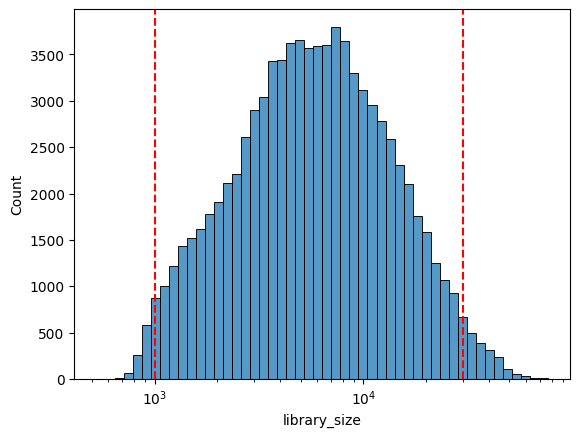

In [4]:
# filter outliars based on the library size (total counts per cell)
adata.obs["library_size"] = adata.layers["total"].sum(axis=1).A1
sns.histplot(adata.obs["library_size"], bins=50, log_scale=True)
min_counts = 1000
max_counts = 30000
plt.axvline(min_counts, color="red", linestyle="--")
plt.axvline(max_counts, color="red", linestyle="--")

In [5]:
adata = adata[
    (adata.obs["library_size"] >= min_counts)
    & (adata.obs["library_size"] <= max_counts)
]
adata

View of AnnData object with n_obs × n_vars = 82455 × 22333
    obs: 'orig_file', 'group', 'n_counts', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'seurat_clusters', 'cancer_type', 'cycling', 'pca_theta', 'histones_fraction', 'inferred_thetas', 'library_size', 'inferred_theta', 'ground_truth_phase'
    layers: 'total'

To reduce training time in this example I will randomly drop 50% of the cells

In [6]:
adata = adata[adata.obs.sample(frac=0.5).index].copy()

## CoPhaser Fitting

We will first define the rhythmic gene sets - genes known to display rhythmic patterns with respect to the cell cycle.

In [7]:
SMALL_CYCLING_GENE_SET = gene_sets.SMALL_CELL_CYCLE_GENE_SET
SMALL_CYCLING_GENE_SET = [
    gene.upper() for gene in SMALL_CYCLING_GENE_SET if gene.upper() in adata.var_names
]
print(f"Number of genes in the small cycling gene set: {len(SMALL_CYCLING_GENE_SET)}")

Number of genes in the small cycling gene set: 98


We will then define the context genes - genes providing enough information to assign cells to different biological contexts. Here and most of the time we just use the 2000 most variable genes.

In [8]:
context_genes = utils.get_variable_genes(adata)

Now we will show examples of fitting failure, and how to detect them and tune the hyperparamters. Here I do not use the Bernoulli VAE, while in a cancer sample we are expecting a lot of G0 like cells.

Epoch 1/200, elbo_loss: 710.47, phase distribution:  ⚠ non-uniform, (summed losses: 395.82)
Epoch 2/200, elbo_loss: 608.60, phase distribution: ~uniform, (summed losses: 273.57)
Epoch 3/200, elbo_loss: 564.44, phase distribution: uniform, (summed losses: 227.83)
Epoch 4/200, elbo_loss: 537.29, phase distribution: uniform, (summed losses: 199.69)
Epoch 5/200, elbo_loss: 518.13, phase distribution: uniform, (summed losses: 180.91)
Epoch 6/200, elbo_loss: 505.13, phase distribution: uniform, (summed losses: 168.86)
Epoch 7/200, elbo_loss: 496.07, phase distribution: uniform, (summed losses: 161.08)
Epoch 8/200, elbo_loss: 490.08, phase distribution: uniform, (summed losses: 155.26)
Epoch 9/200, elbo_loss: 486.51, phase distribution: uniform, (summed losses: 150.69)
Epoch 10/200, elbo_loss: 483.79, phase distribution: uniform, (summed losses: 147.86)
Epoch 11/200, elbo_loss: 480.47, phase distribution: uniform, (summed losses: 146.14)
Epoch 12/200, elbo_loss: 477.65, phase distribution: un

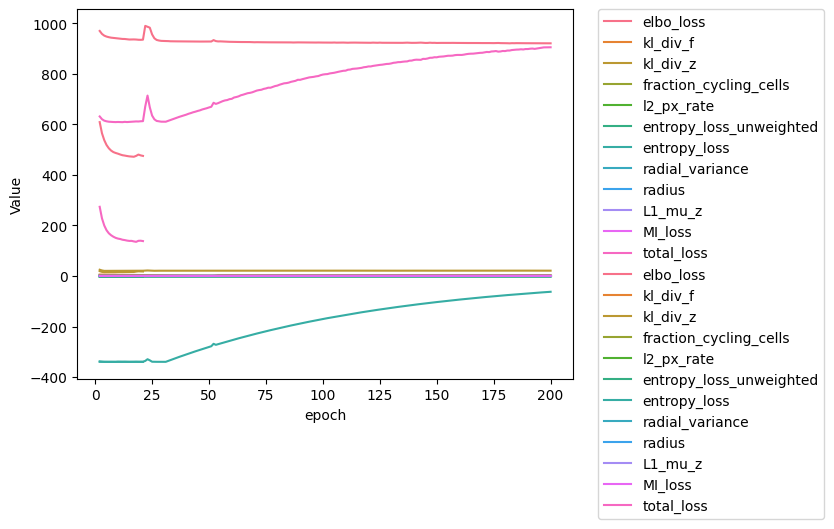

In [9]:
model = CoPhaser(
    SMALL_CYCLING_GENE_SET,
    context_genes=context_genes,
)
model.load_anndata(adata, layer_to_use="total")
trainer = Trainer(
    model,
    Loss.compute_loss,
)
trainer.train_model()

<Axes: ylabel='Count'>

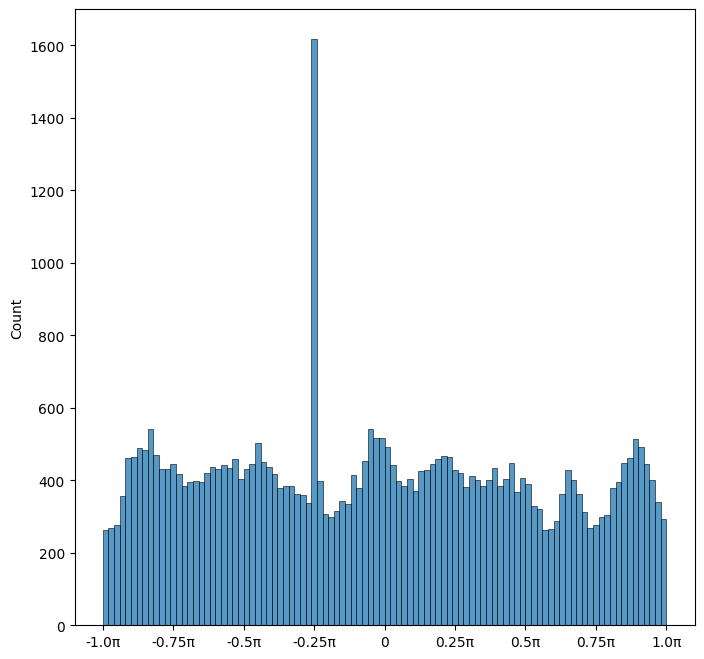

In [10]:
# Get the infered theta values
model.to("cpu")
generative_outputs, space_outputs = model.get_outputs()
thetas = space_outputs["theta"]
plotting.modify_axis_labels()
sns.histplot(thetas, bins=100)

54 histone genes found in data
Getting posterior and calculating entropy...


100%|██████████| 20/20 [00:01<00:00, 19.32it/s]


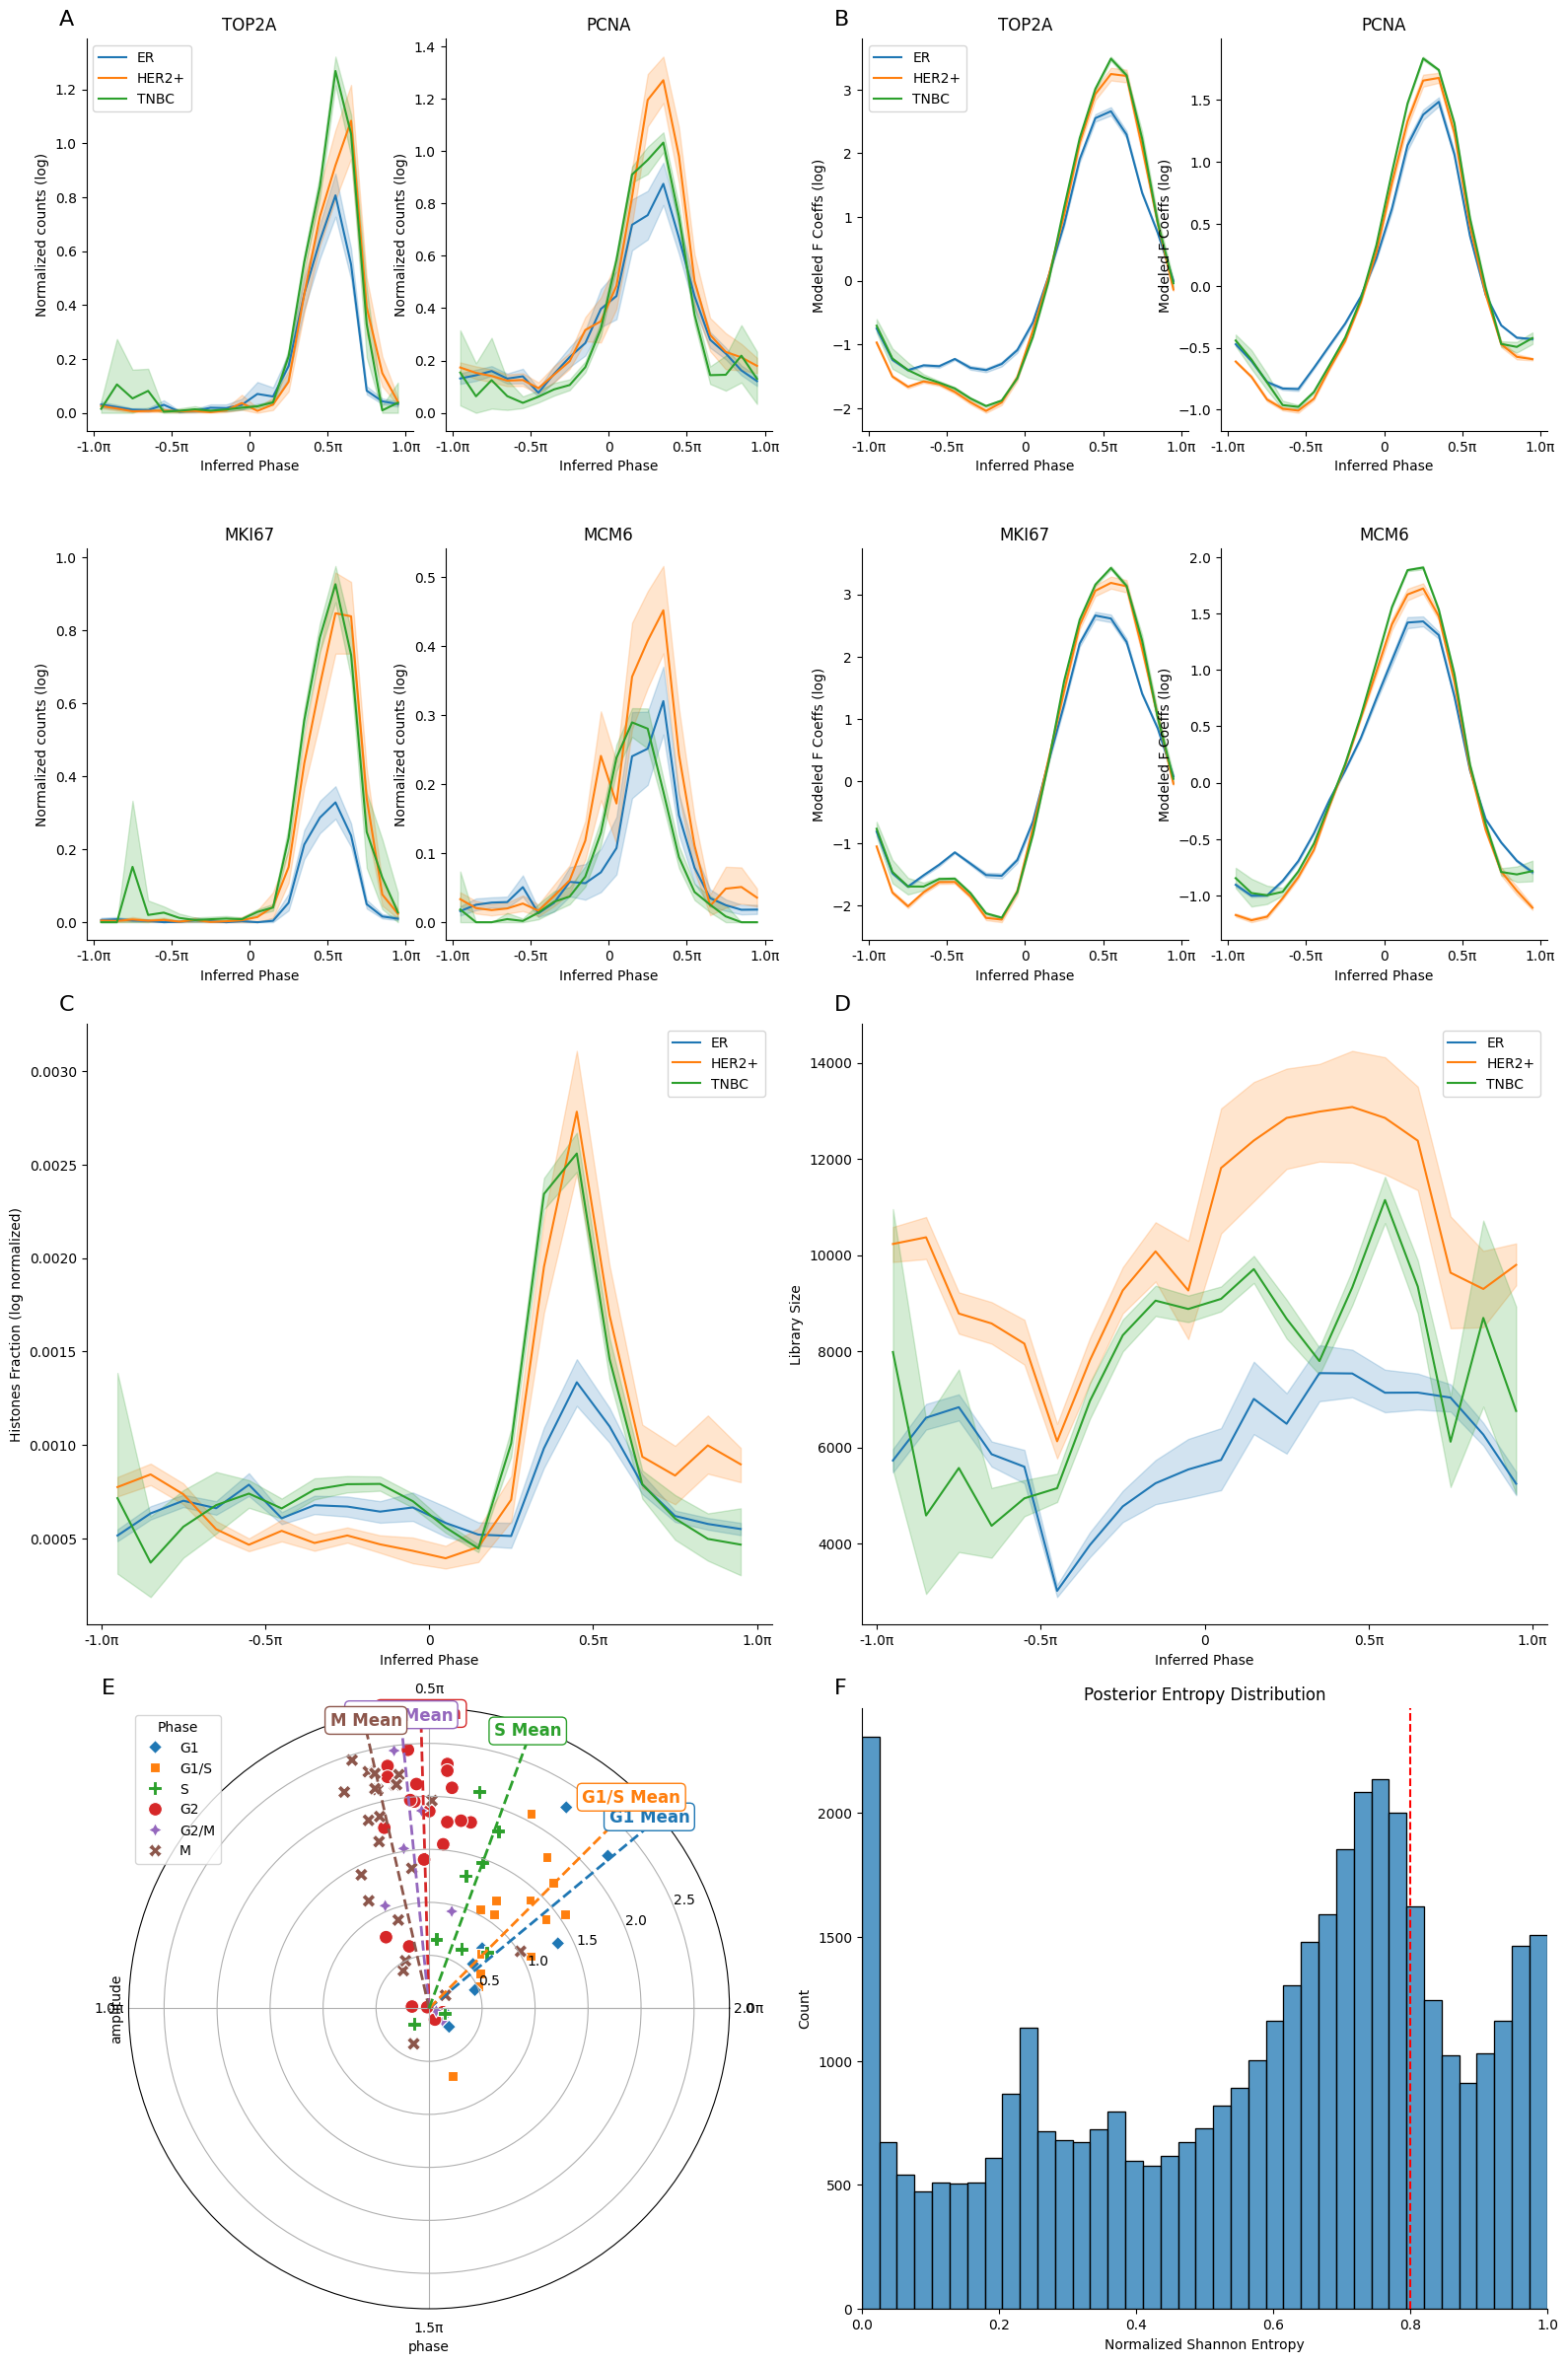

Validation of the inferred cell cycle phases.

A. Reconstructed gene expression profiles, obtained by binning cells according to inferred phase and averaging 
log(1 + counts per 10,000) for the indicated gene.
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.
If Top2a/Mki67 are not in phase and phase shifted with respect to Pcna/Mcm6, the inferred phases are wrong.)

B. Fourier derived predicted gene expression profiles in log
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.)

C. Histone fraction in function of inferred phase.
(You should see a peak during the S phase (see D and E to determine the S phase).)

D. Library size in function of inferred phase.
(You should ~see a doubling of the library size.)

E. Scatter plot of the inferred peaking phases and amplitudes of annotated cell cycle genes.
(You should ~see a progression from G1-G1/S-S-G2-M.)

F. Distribution

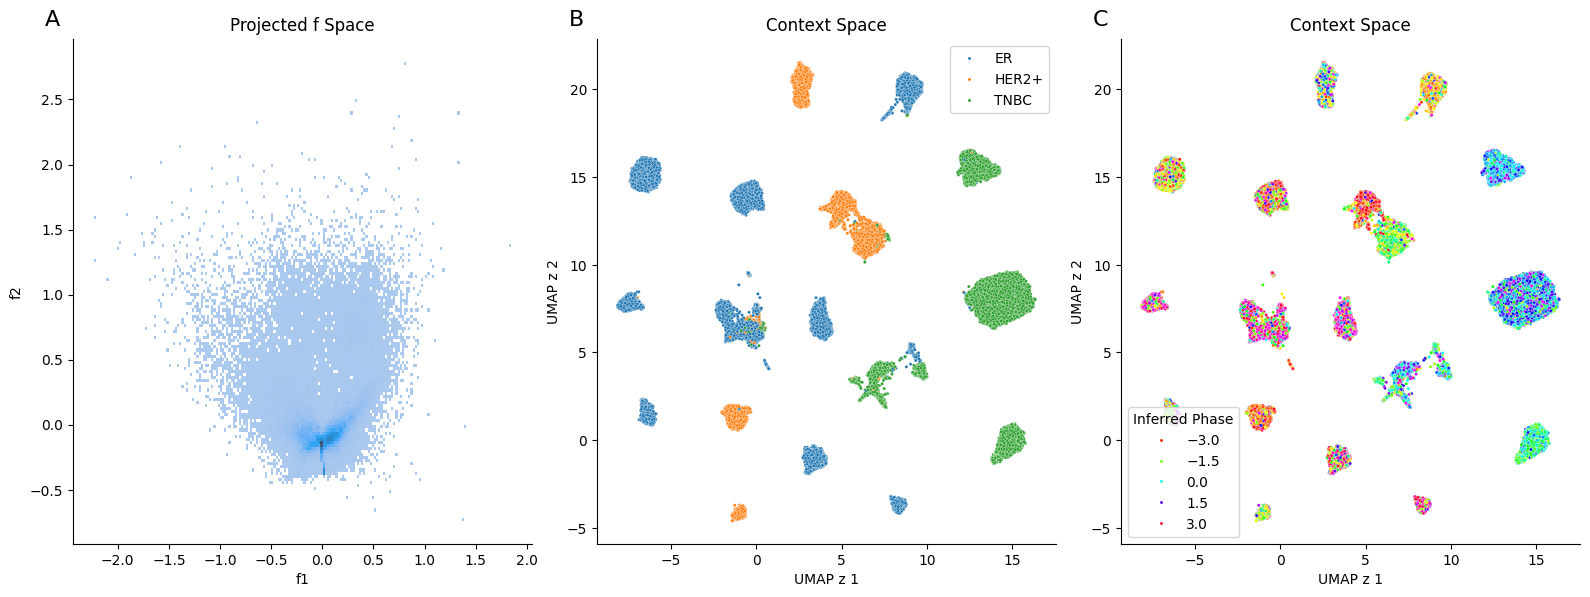

Latent space visualization of the inferred cell cycle phases.
    
A. Histogram of the projected f space, which defines the inferred phase. 
(Seeing an annulus is a good signal, but this depends on the weight of Trainer's closed_circle_weight)

B. Context space colored by the provided hue (if any).

C. Context space colored by the inferred phase. 
(You should see a ~ random distribution of the inferred phases in the context space, since the mutual
information between the context and the inferred phase is minimized.)



In [11]:
plotting.plot_cell_cycle_validations(
    model,
    space_outputs,
    generative_outputs,
    adata,
    layer="total",
    hue_key="cancer_type",
)

Here you can see that everything looks fine except F, and the cycle is compressed to a small interval. As we show in the paper, having high fraction of uncertain cells (pannel F) is a sign that the Bernoulli VAE is required to handle the G0 like cells.

## With the Bernoulli VAE

Epoch 1/200, elbo_loss: 703.53, phase distribution:  ⚠ non-uniform, (summed losses: 406.63)
Epoch 2/200, elbo_loss: 604.63, phase distribution:  ⚠ non-uniform, (summed losses: 272.04)
Epoch 3/200, elbo_loss: 561.53, phase distribution: ~uniform, (summed losses: 225.86)
Epoch 4/200, elbo_loss: 533.17, phase distribution: uniform, (summed losses: 196.02)
Epoch 5/200, elbo_loss: 513.72, phase distribution: uniform, (summed losses: 176.82)
Epoch 6/200, elbo_loss: 499.93, phase distribution: uniform, (summed losses: 162.95)
Epoch 7/200, elbo_loss: 489.91, phase distribution: uniform, (summed losses: 153.29)
Epoch 8/200, elbo_loss: 482.11, phase distribution: uniform, (summed losses: 146.74)
Epoch 9/200, elbo_loss: 476.31, phase distribution: uniform, (summed losses: 142.04)
Epoch 10/200, elbo_loss: 472.49, phase distribution: uniform, (summed losses: 138.96)
Epoch 11/200, elbo_loss: 469.54, phase distribution: uniform, (summed losses: 136.38)
Epoch 12/200, elbo_loss: 472.53, phase distribut

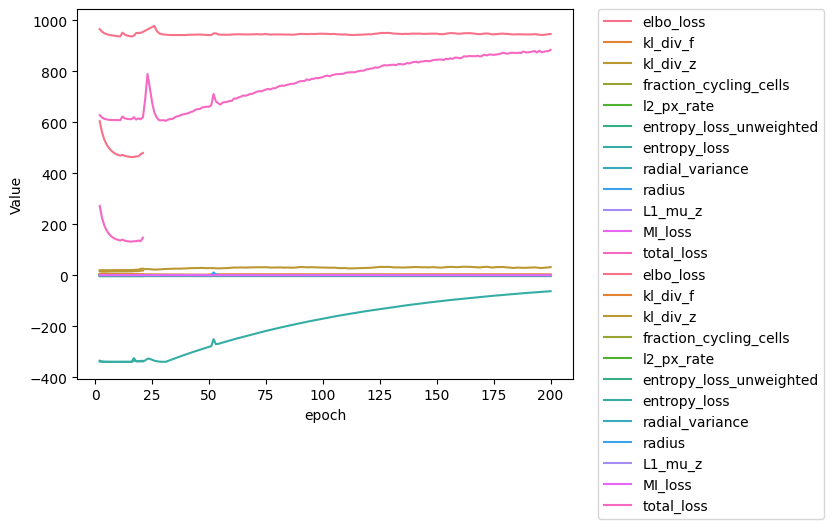

In [ ]:
model = CoPhaser(
    SMALL_CYCLING_GENE_SET,
    context_genes=context_genes,
)
model.load_anndata(adata, layer_to_use="total")
f_coeffs_path = (
    resources.files("CoPhaser") / "resources" / "fourier_coefficients_RPE.csv"
)
VAEModelLoader.load_fourier_coefficients_prior(f_coeffs_path, model)
trainer = Trainer(
    model,
    Loss.compute_loss,
    cycling_status_prior=0.1,
    unfreeze_epoch_layer=[(20, "rhythmic_decoder")],
)
trainer.train_model()

<Axes: xlabel='None', ylabel='Count'>

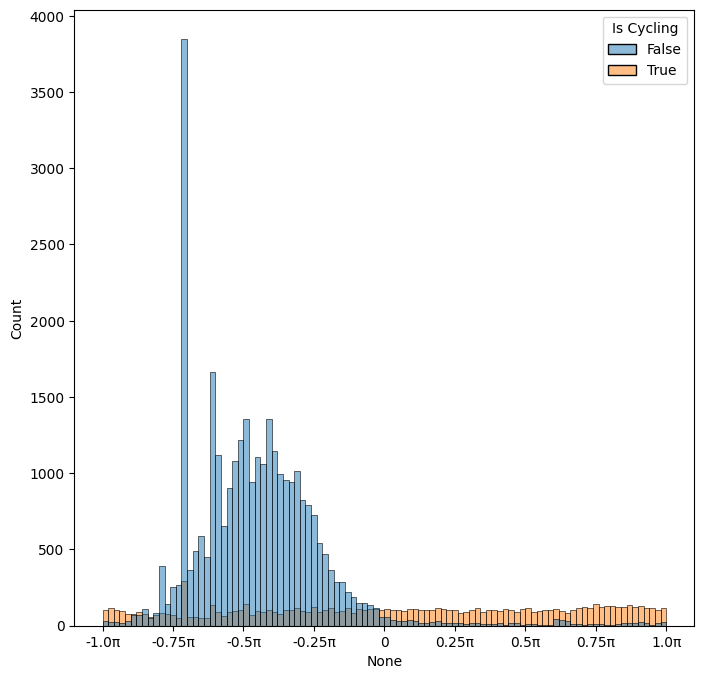

In [44]:
# Get the infered theta values
model.to("cpu")
generative_outputs, space_outputs = model.get_outputs()
thetas = space_outputs["theta"]
plotting.modify_axis_labels()
cycling_cells = space_outputs["b_z"].detach().cpu().numpy() > 0.5
cycling_cells = pd.Series(cycling_cells, name="Is Cycling")
sns.histplot(x=thetas, hue=cycling_cells, bins=100)

54 histone genes found in data
Getting posterior and calculating entropy...


100%|██████████| 20/20 [00:01<00:00, 19.36it/s]


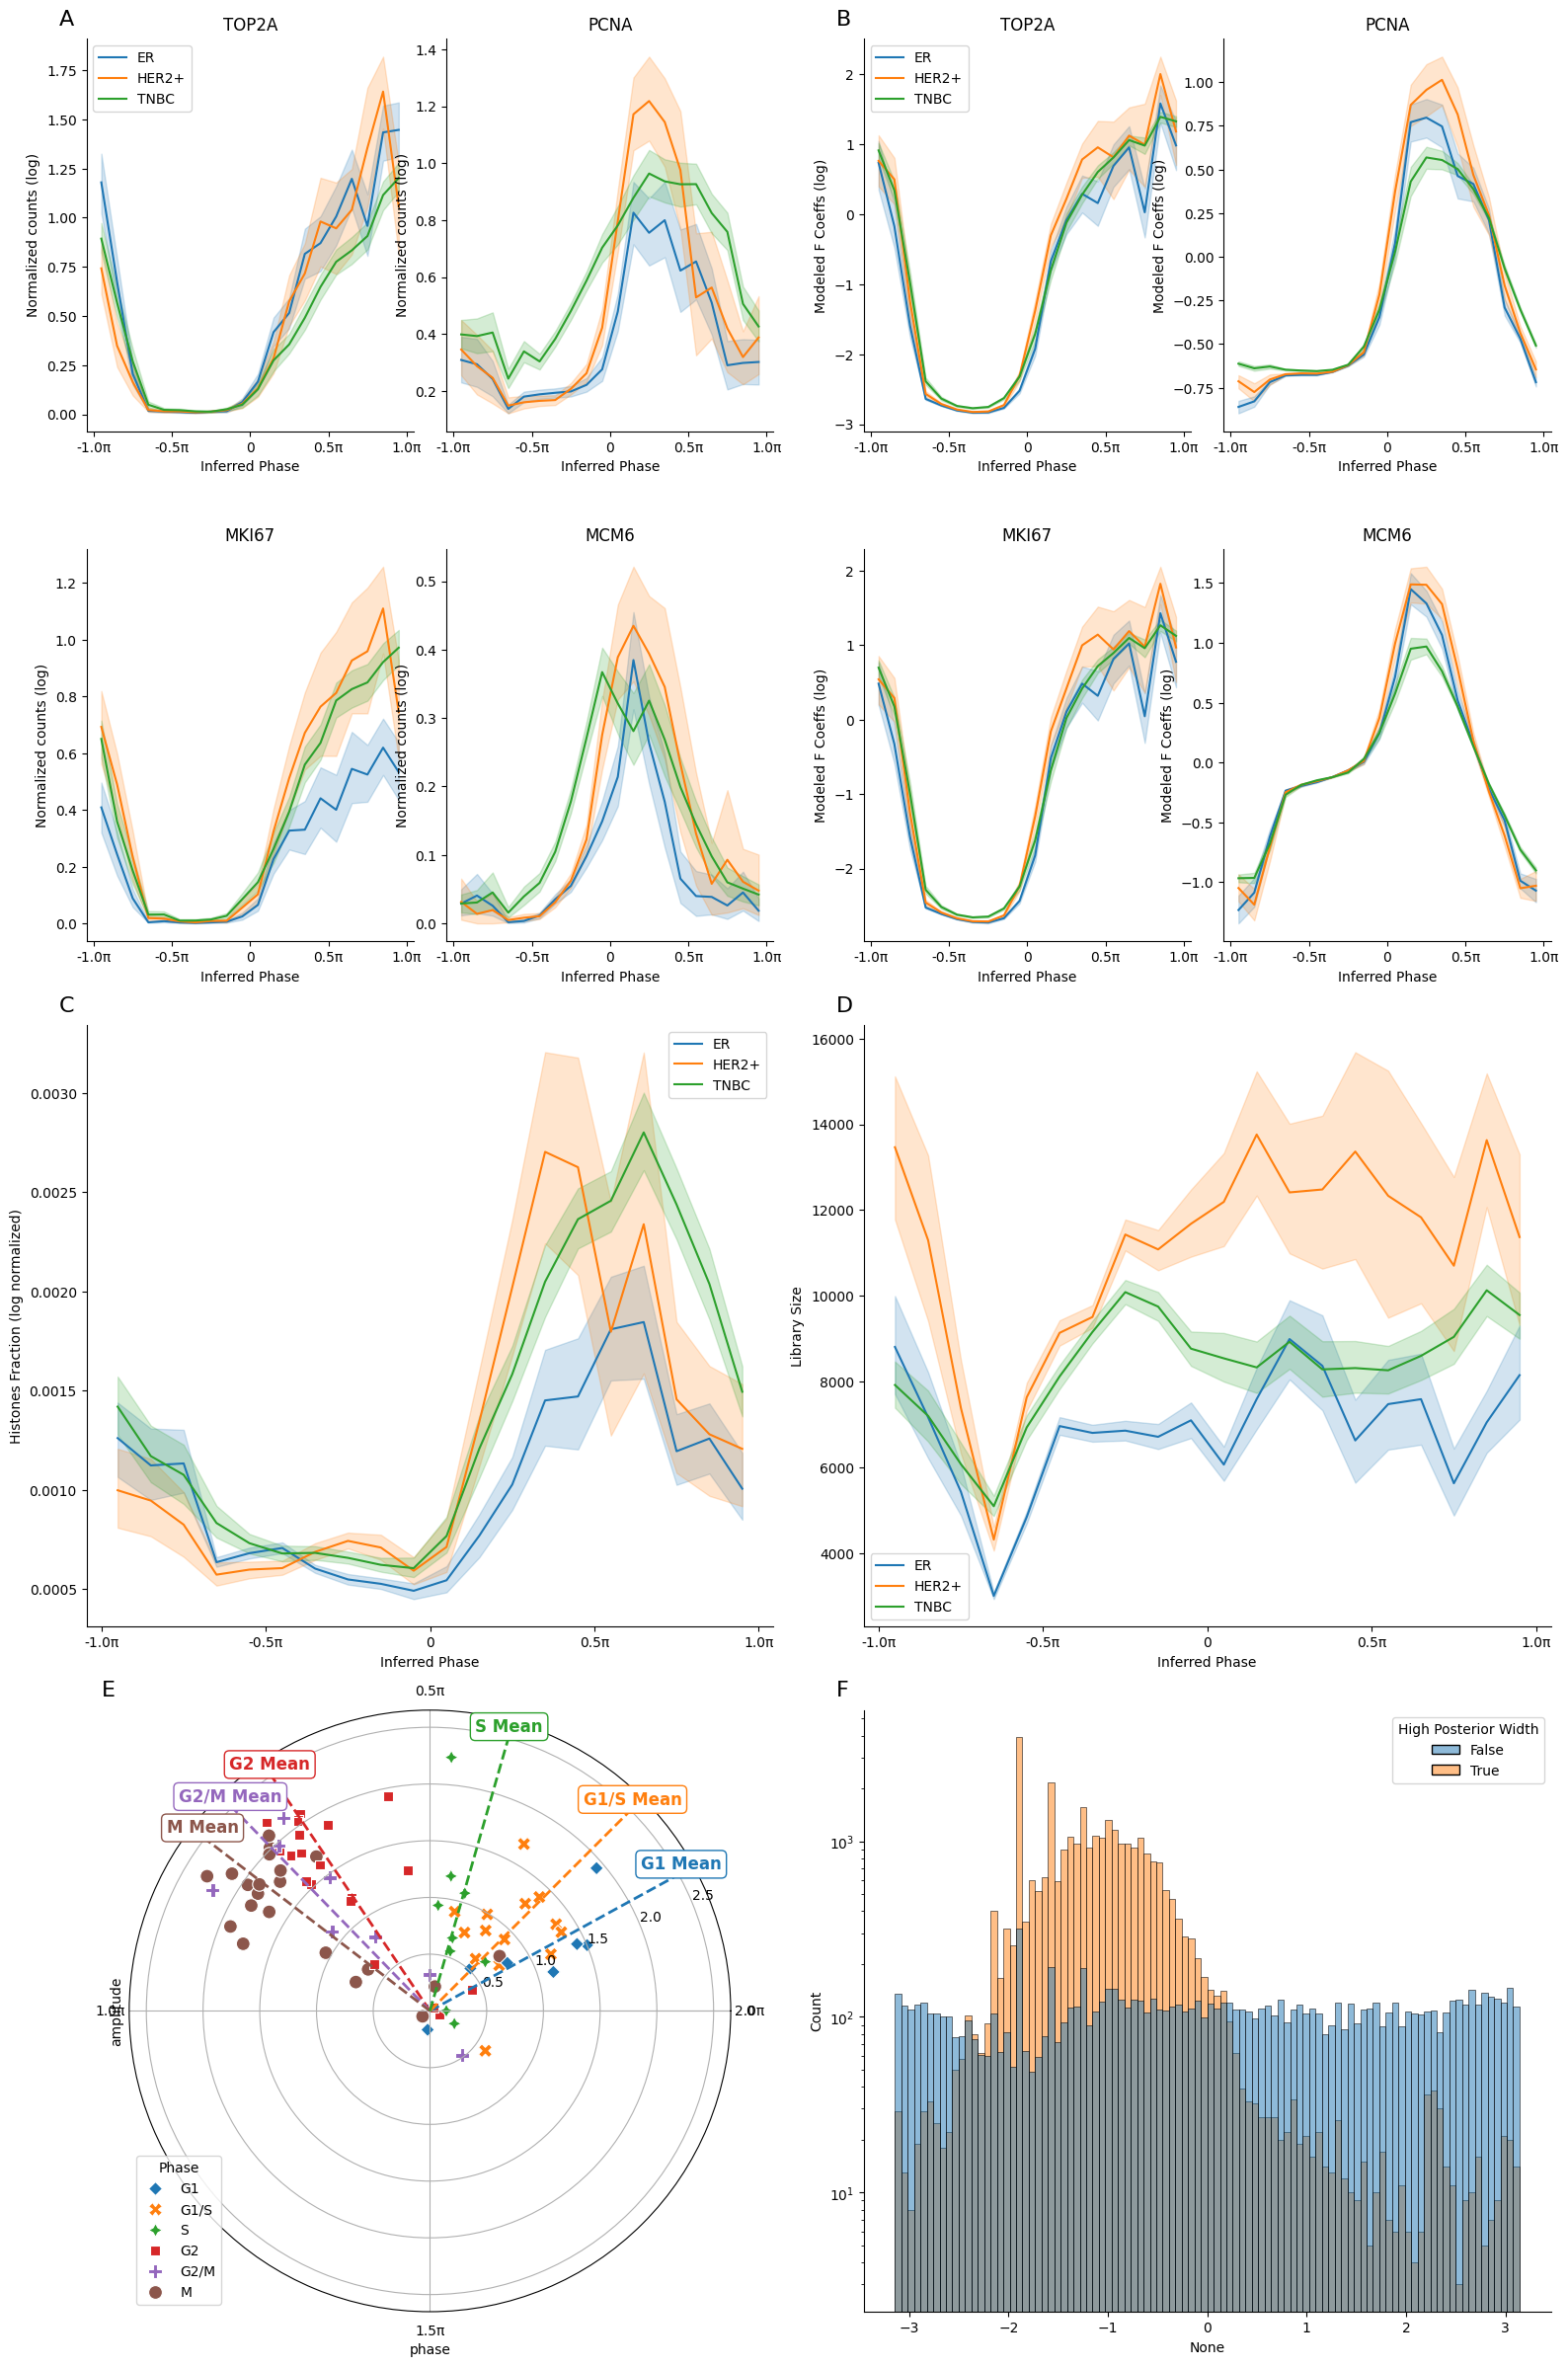

Validation of the inferred cell cycle phases.

A. Reconstructed gene expression profiles, obtained by binning cells according to inferred phase and averaging 
log(1 + counts per 10,000) for the indicated gene.
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.
If Top2a/Mki67 are not in phase and phase shifted with respect to Pcna/Mcm6, the inferred phases are wrong.)

B. Fourier derived predicted gene expression profiles in log
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.)

C. Histone fraction in function of inferred phase.
(You should see a peak during the S phase (see D and E to determine the S phase).)

D. Library size in function of inferred phase.
(You should ~see a doubling of the library size.)

E. Scatter plot of the inferred peaking phases and amplitudes of annotated cell cycle genes.
(You should ~see a progression from G1-G1/S-S-G2-M.)

F. Distribution

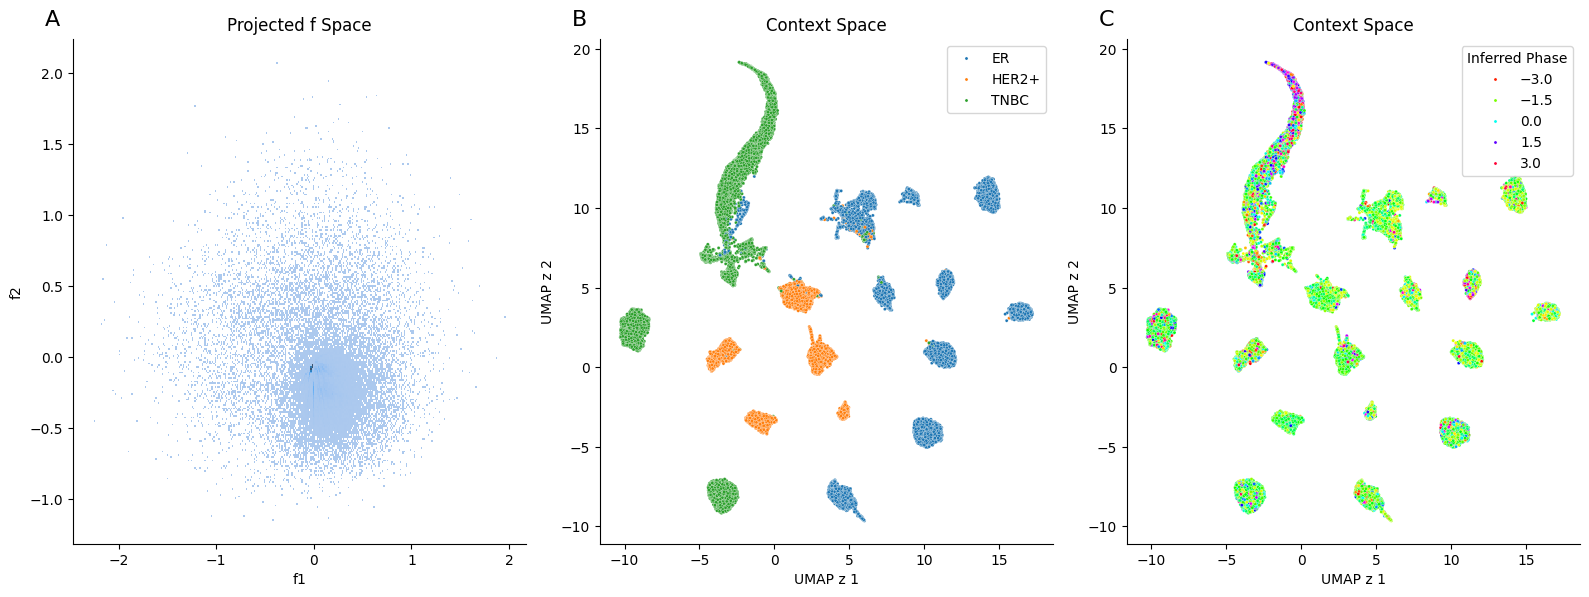

Latent space visualization of the inferred cell cycle phases.
    
A. Histogram of the projected f space, which defines the inferred phase. 
(Seeing an annulus is a good signal, but this depends on the weight of Trainer's closed_circle_weight)

B. Context space colored by the provided hue (if any).

C. Context space colored by the inferred phase. 
(You should see a ~ random distribution of the inferred phases in the context space, since the mutual
information between the context and the inferred phase is minimized.)



In [47]:
plotting.plot_cell_cycle_validations(
    model,
    space_outputs,
    generative_outputs,
    adata,
    layer="total",
    hue_key="cancer_type",
)

Now the cycle expanded (E) and the amplitudes increased (Top2a: 1.75 log (A) for instance), but in F we can see that some cells with large posteriors are still set to the S-G2-M area, which is unwanted, they are suppose to be only in G1/G0 (all cell cycle counts close to 0). This is not dramatic, but the precision can typically be improved by increasing the weight of the ``rhythmic_likelihood_weight``, and since in second pannel A the Projected f space is not circular we can try to increase the ``closed_circle_weight``.

## Fine tunning

Epoch 1/200, elbo_loss: 842.40, phase distribution:  ⚠ non-uniform, (summed losses: 556.78)
Epoch 2/200, elbo_loss: 720.12, phase distribution:  ⚠ non-uniform, (summed losses: 396.69)
Epoch 3/200, elbo_loss: 670.36, phase distribution: slightly non-uniform, (summed losses: 339.55)
Epoch 4/200, elbo_loss: 639.31, phase distribution: uniform, (summed losses: 306.45)
Epoch 5/200, elbo_loss: 620.12, phase distribution: uniform, (summed losses: 288.32)
Epoch 6/200, elbo_loss: 607.62, phase distribution: uniform, (summed losses: 276.83)
Epoch 7/200, elbo_loss: 598.72, phase distribution: uniform, (summed losses: 269.50)
Epoch 8/200, elbo_loss: 592.32, phase distribution: uniform, (summed losses: 263.92)
Epoch 9/200, elbo_loss: 587.80, phase distribution: uniform, (summed losses: 259.91)
Epoch 10/200, elbo_loss: 584.03, phase distribution: uniform, (summed losses: 256.40)
Epoch 11/200, elbo_loss: 580.46, phase distribution: uniform, (summed losses: 252.63)
Epoch 12/200, elbo_loss: 596.93, pha

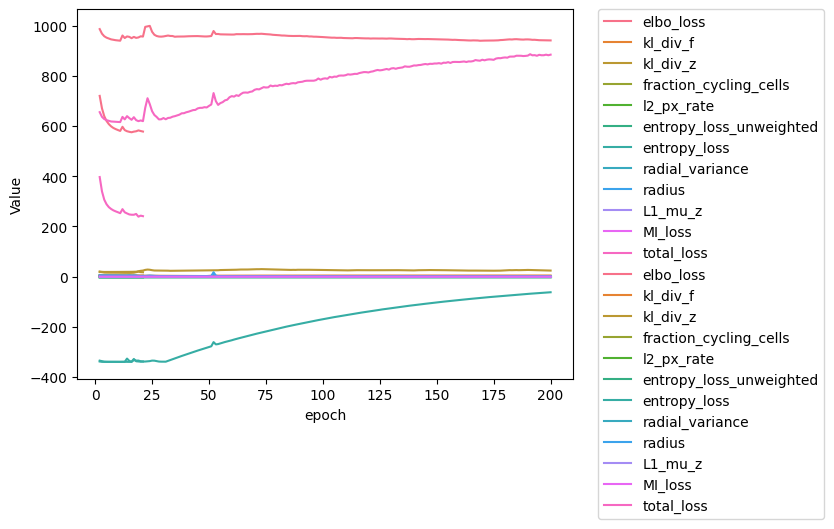

In [61]:
model = CoPhaser(
    SMALL_CYCLING_GENE_SET,
    context_genes=context_genes,
)
model.load_anndata(adata, layer_to_use="total")
f_coeffs_path = (
    resources.files("CoPhaser") / "resources" / "fourier_coefficients_RPE.csv"
)
VAEModelLoader.load_fourier_coefficients_prior(f_coeffs_path, model)
trainer = Trainer(
    model,
    Loss.compute_loss,
    cycling_status_prior=0.1,
    closed_circle_weight=10,
    rhythmic_likelihood_weight=4,
    unfreeze_epoch_layer=[(20, "rhythmic_decoder")],
)
trainer.train_model()

<Axes: xlabel='None', ylabel='Count'>

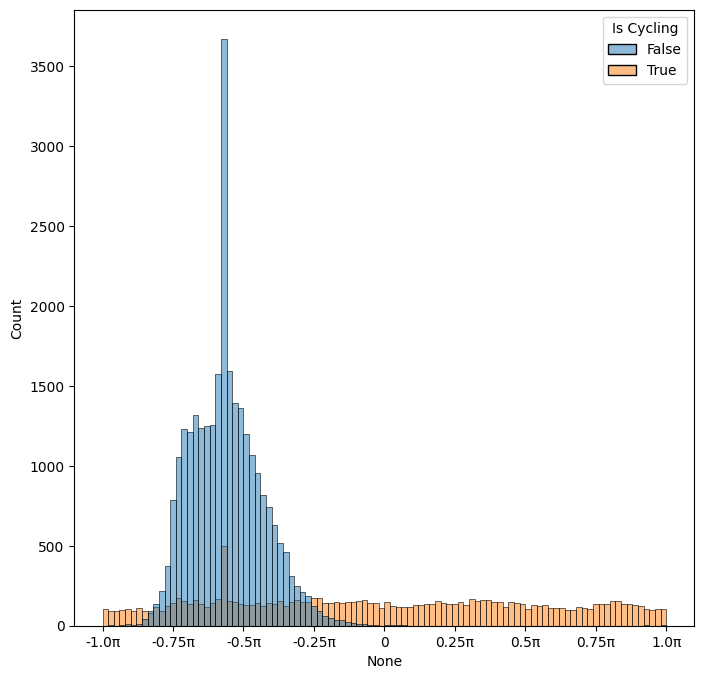

In [62]:
# Get the infered theta values
model.to("cpu")
generative_outputs, space_outputs = model.get_outputs()
thetas = space_outputs["theta"]
plotting.modify_axis_labels()
cycling_cells = space_outputs["b_z"].detach().cpu().numpy() > 0.5
cycling_cells = pd.Series(cycling_cells, name="Is Cycling")
sns.histplot(x=thetas, hue=cycling_cells, bins=100)

54 histone genes found in data
Getting posterior and calculating entropy...


100%|██████████| 20/20 [00:01<00:00, 19.31it/s]


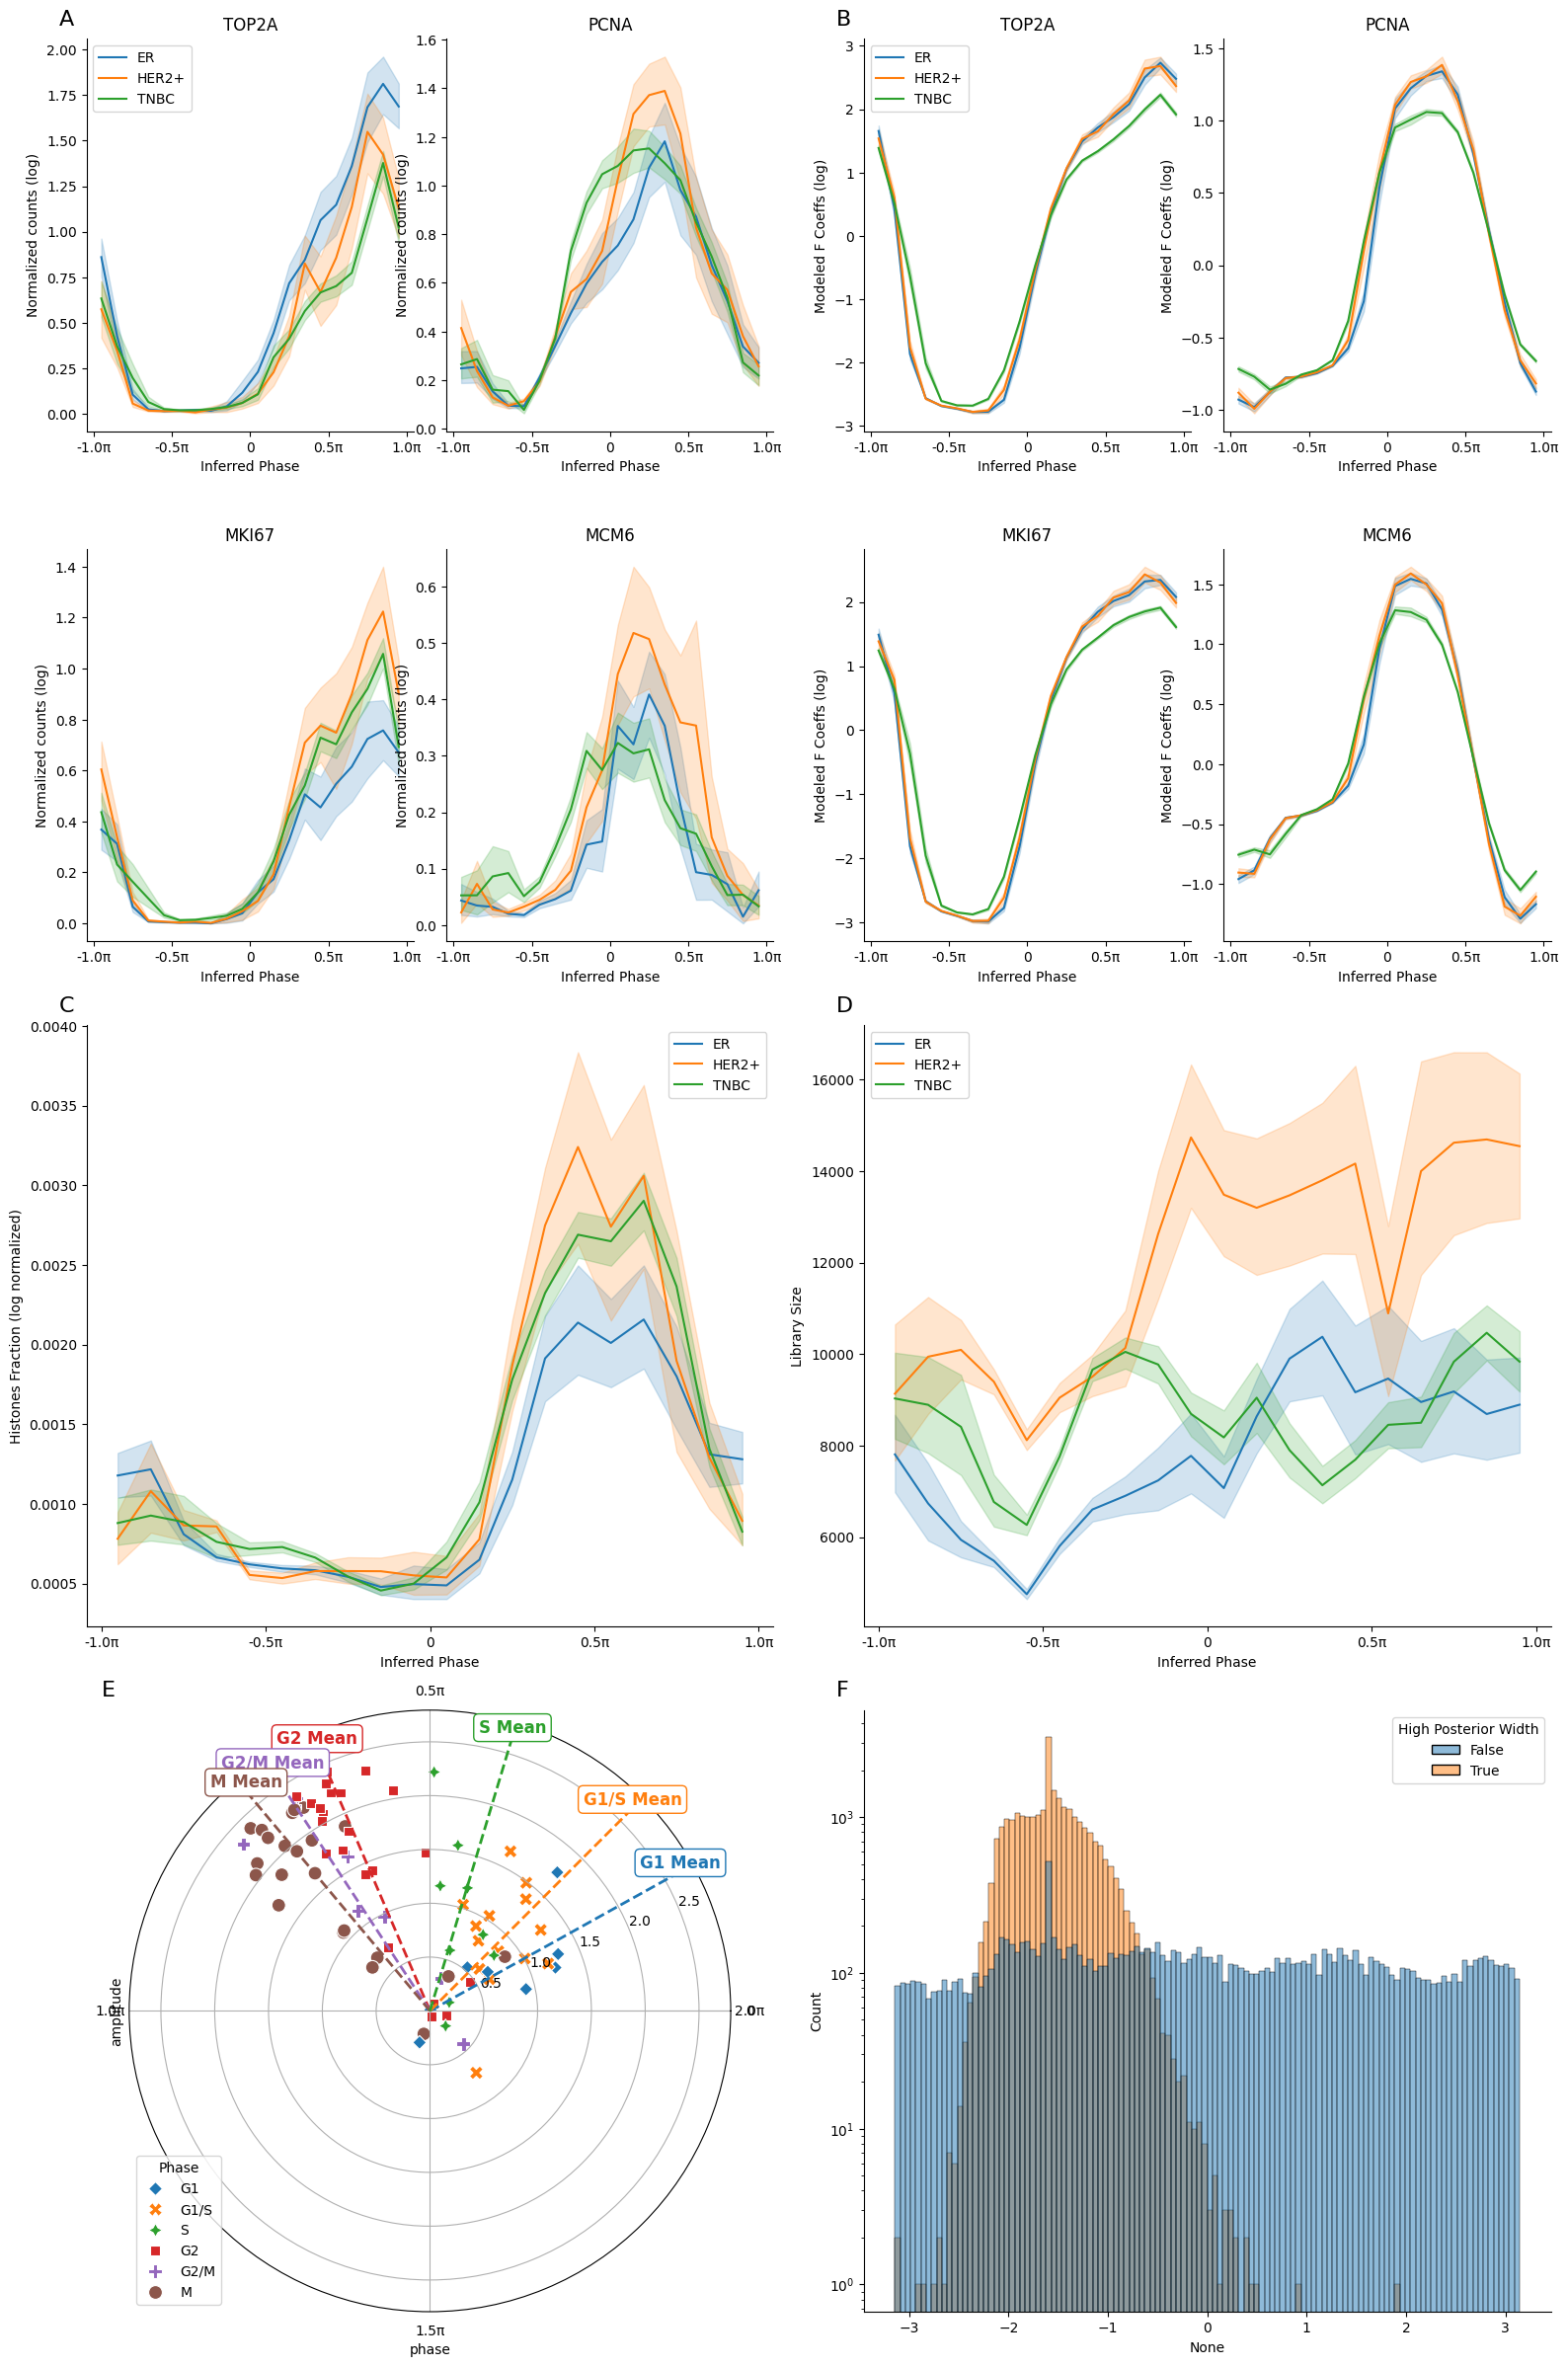

Validation of the inferred cell cycle phases.

A. Reconstructed gene expression profiles, obtained by binning cells according to inferred phase and averaging 
log(1 + counts per 10,000) for the indicated gene.
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.
If Top2a/Mki67 are not in phase and phase shifted with respect to Pcna/Mcm6, the inferred phases are wrong.)

B. Fourier derived predicted gene expression profiles in log
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.)

C. Histone fraction in function of inferred phase.
(You should see a peak during the S phase (see D and E to determine the S phase).)

D. Library size in function of inferred phase.
(You should ~see a doubling of the library size.)

E. Scatter plot of the inferred peaking phases and amplitudes of annotated cell cycle genes.
(You should ~see a progression from G1-G1/S-S-G2-M.)

F. Distribution

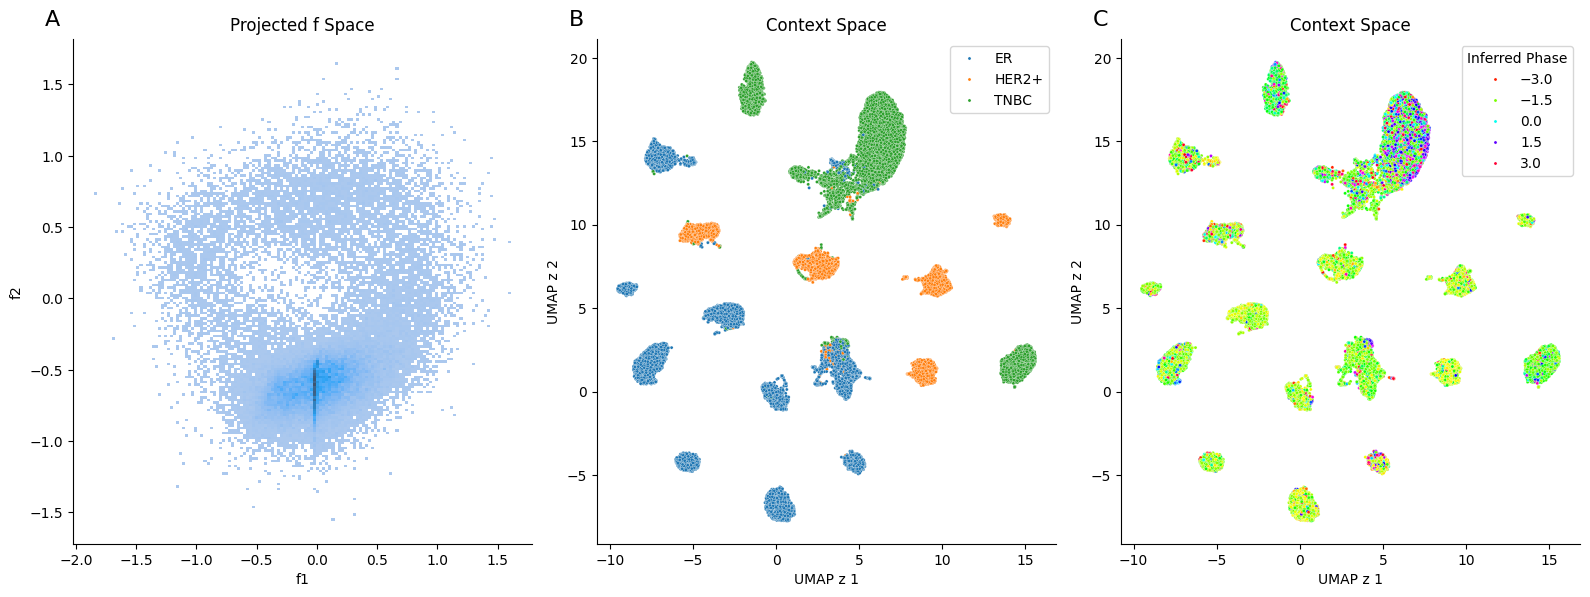

Latent space visualization of the inferred cell cycle phases.
    
A. Histogram of the projected f space, which defines the inferred phase. 
(Seeing an annulus is a good signal, but this depends on the weight of Trainer's closed_circle_weight)

B. Context space colored by the provided hue (if any).

C. Context space colored by the inferred phase. 
(You should see a ~ random distribution of the inferred phases in the context space, since the mutual
information between the context and the inferred phase is minimized.)



In [63]:
plotting.plot_cell_cycle_validations(
    model,
    space_outputs,
    generative_outputs,
    adata,
    layer="total",
    hue_key="cancer_type",
)

As you can see this improved the results, with even higher amplitudes on Top2a, histones and no wide posterior cells on the active phases of the cycle. Increasing the amplitudes of seed genes and histones is a sign that the inferred phases captures better the cycle.

## Typical failures

We will use the cycling cells to showcase some typical failures

In [64]:
adata = adata[cycling_cells.values].copy()

Epoch 1/200, elbo_loss: 737.42, phase distribution:  ⚠ non-uniform, (summed losses: 708.45)
Epoch 2/200, elbo_loss: 638.47, phase distribution:  ⚠ non-uniform, (summed losses: 606.41)
Epoch 3/200, elbo_loss: 600.83, phase distribution: slightly non-uniform, (summed losses: 569.17)
Epoch 4/200, elbo_loss: 579.57, phase distribution: slightly non-uniform, (summed losses: 549.91)
Epoch 5/200, elbo_loss: 566.58, phase distribution: ~uniform, (summed losses: 539.47)
Epoch 6/200, elbo_loss: 557.45, phase distribution:  ⚠ non-uniform, (summed losses: 531.65)
Epoch 7/200, elbo_loss: 550.78, phase distribution: ~uniform, (summed losses: 524.95)
Epoch 8/200, elbo_loss: 548.26, phase distribution: ~uniform, (summed losses: 515.50)
Epoch 9/200, elbo_loss: 547.78, phase distribution: ~uniform, (summed losses: 515.69)
Epoch 10/200, elbo_loss: 541.24, phase distribution: ~uniform, (summed losses: 514.18)
Epoch 11/200, elbo_loss: 539.80, phase distribution: ~uniform, (summed losses: 509.00)
Epoch 12/2

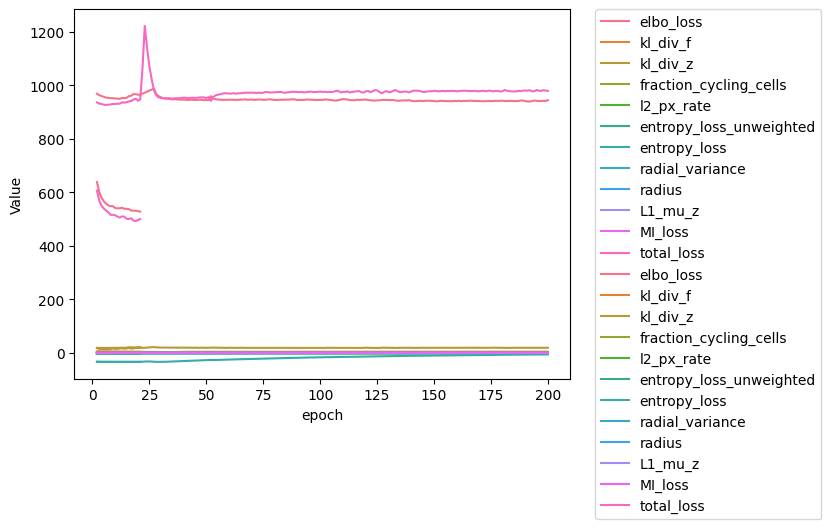

In [71]:
model = CoPhaser(
    SMALL_CYCLING_GENE_SET,
    context_genes=context_genes,
)
model.load_anndata(adata, layer_to_use="total")
trainer = Trainer(
    model,
    Loss.compute_loss,
    entropy_weight_factor=10,
)
trainer.train_model()

<Axes: xlabel='None', ylabel='Count'>

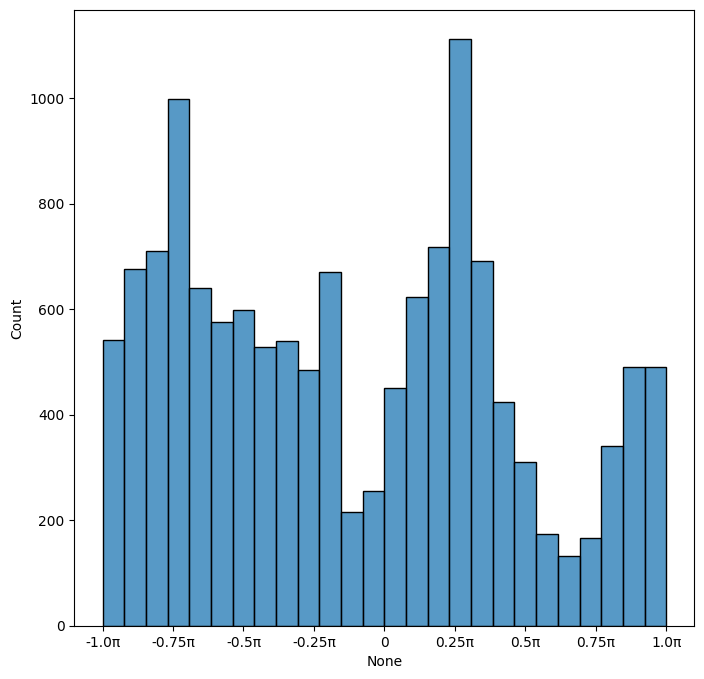

In [72]:
# Get the infered theta values
model.to("cpu")
generative_outputs, space_outputs = model.get_outputs()
thetas = space_outputs["theta"]
plotting.modify_axis_labels()
sns.histplot(x=thetas)

54 histone genes found in data
Getting posterior and calculating entropy...


100%|██████████| 20/20 [00:00<00:00, 57.05it/s]


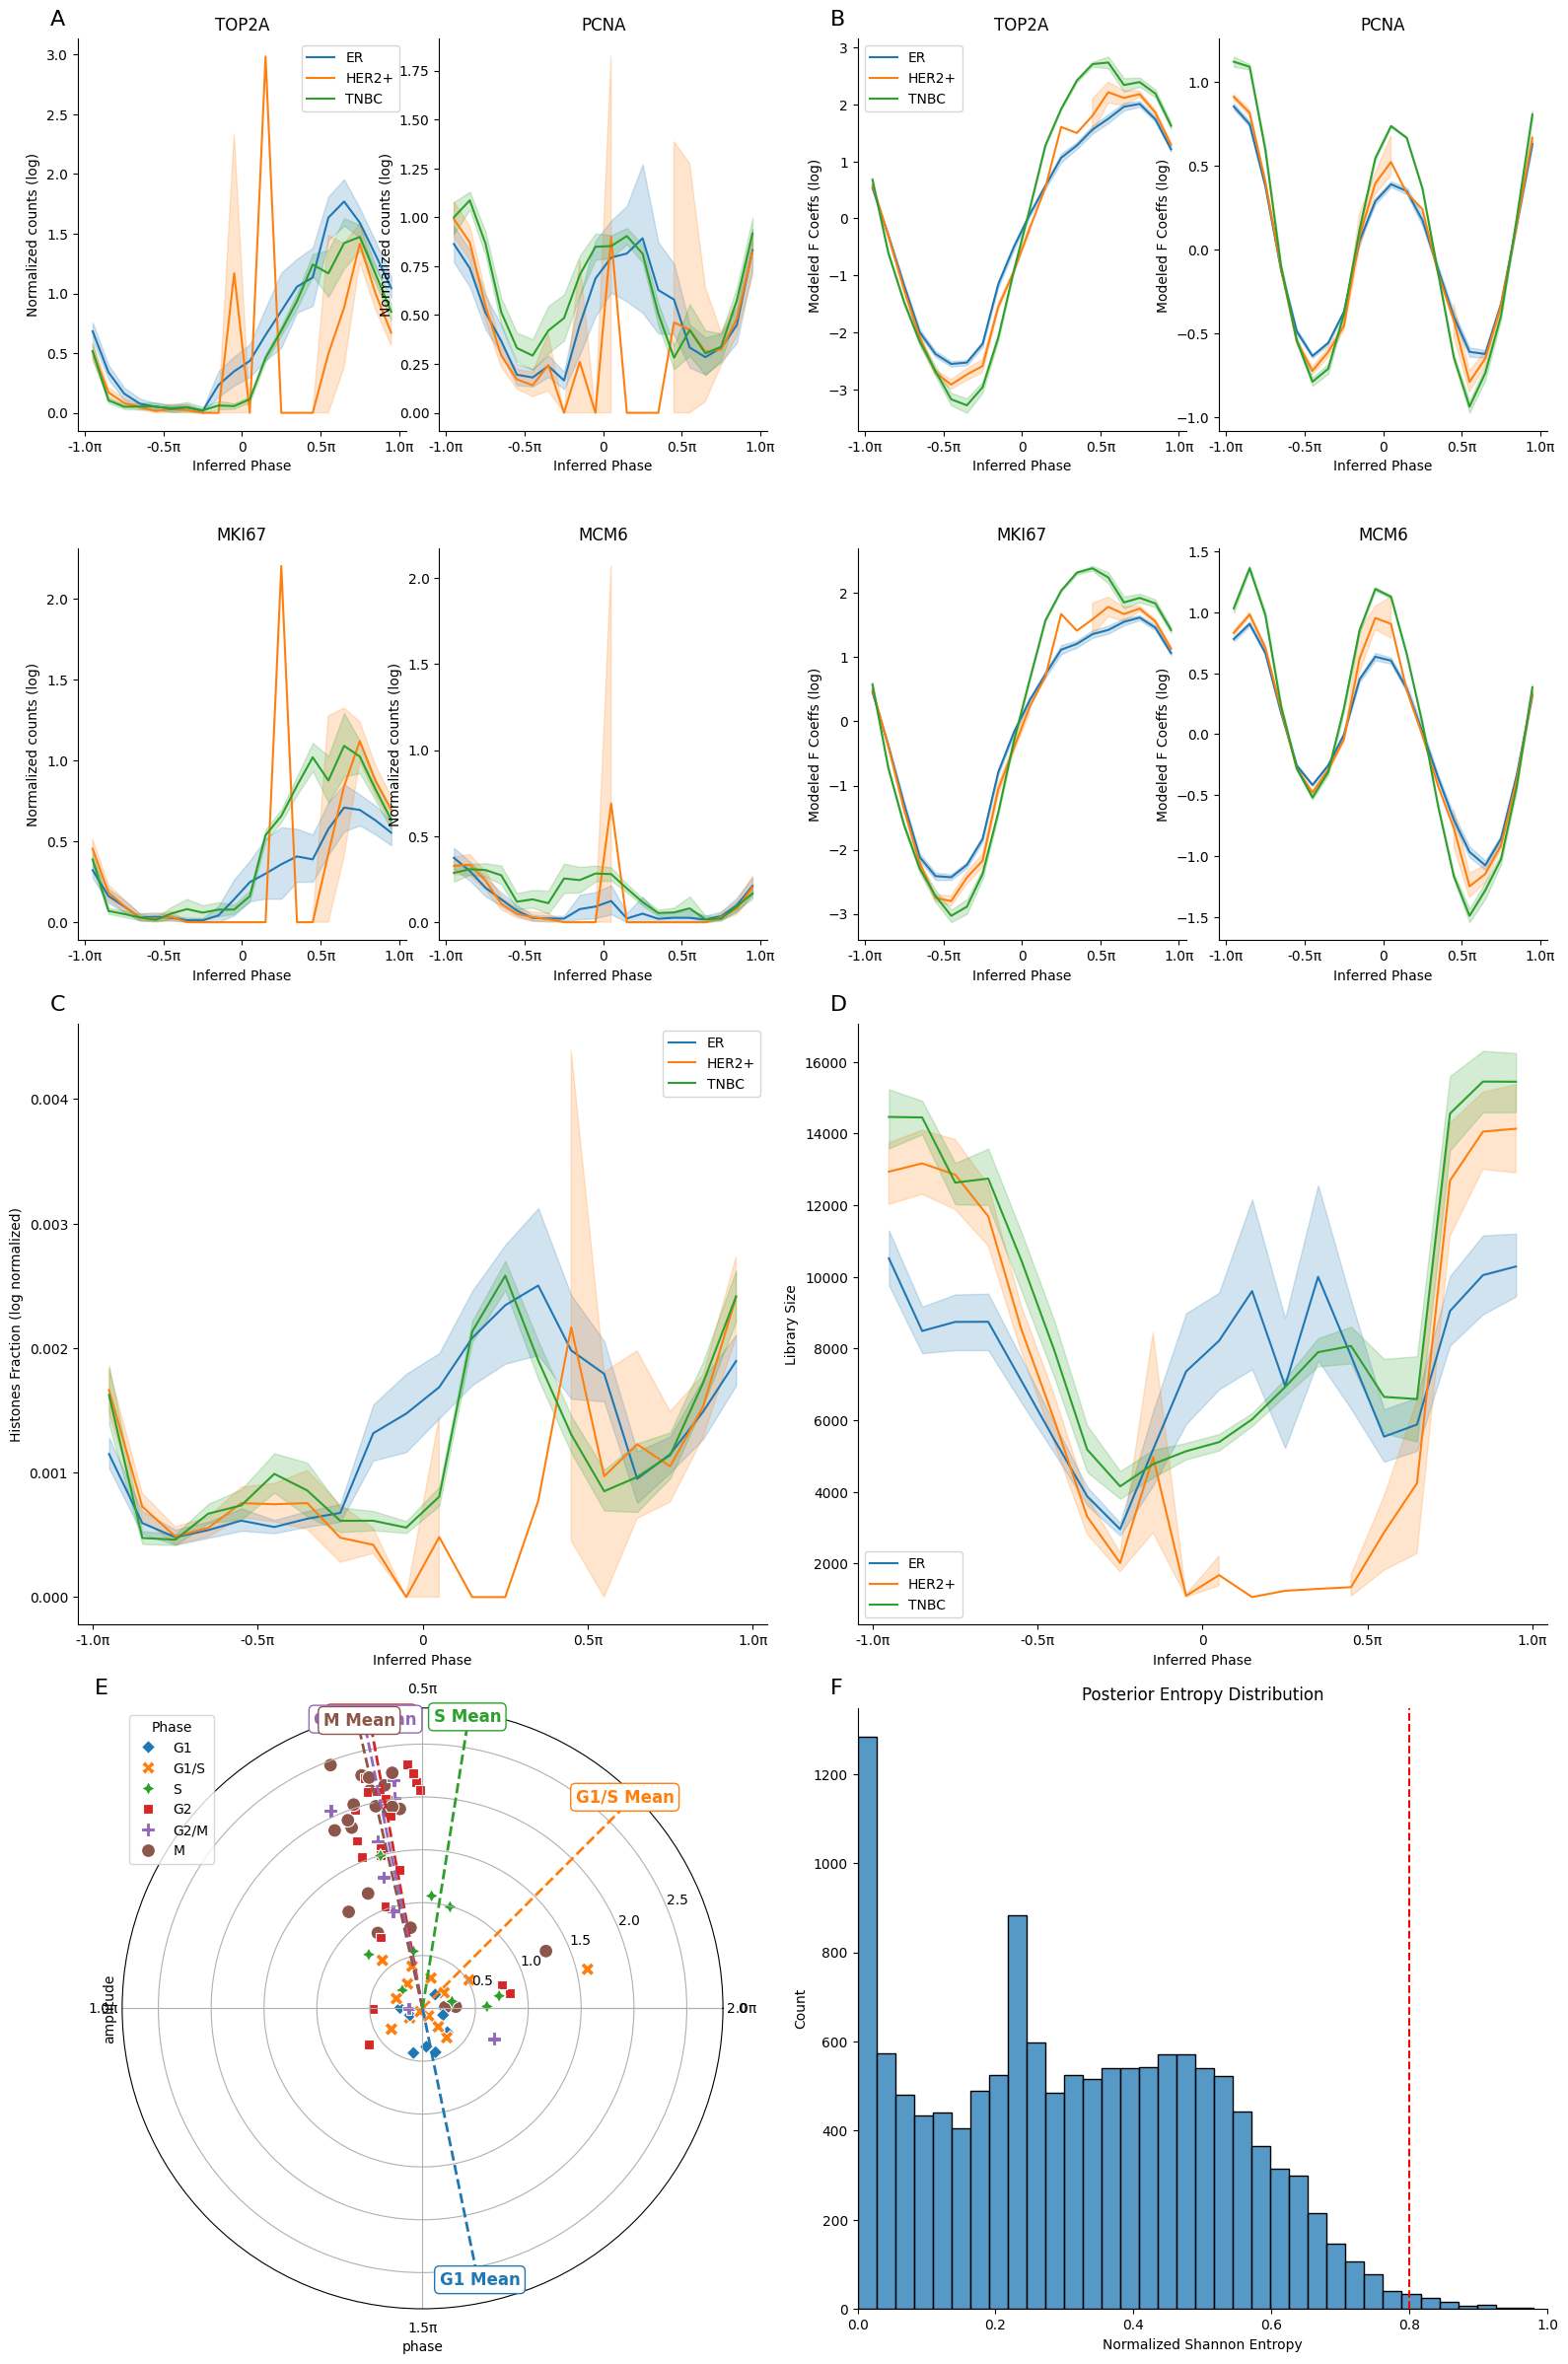

Validation of the inferred cell cycle phases.

A. Reconstructed gene expression profiles, obtained by binning cells according to inferred phase and averaging 
log(1 + counts per 10,000) for the indicated gene.
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.
If Top2a/Mki67 are not in phase and phase shifted with respect to Pcna/Mcm6, the inferred phases are wrong.)

B. Fourier derived predicted gene expression profiles in log
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.)

C. Histone fraction in function of inferred phase.
(You should see a peak during the S phase (see D and E to determine the S phase).)

D. Library size in function of inferred phase.
(You should ~see a doubling of the library size.)

E. Scatter plot of the inferred peaking phases and amplitudes of annotated cell cycle genes.
(You should ~see a progression from G1-G1/S-S-G2-M.)

F. Distribution

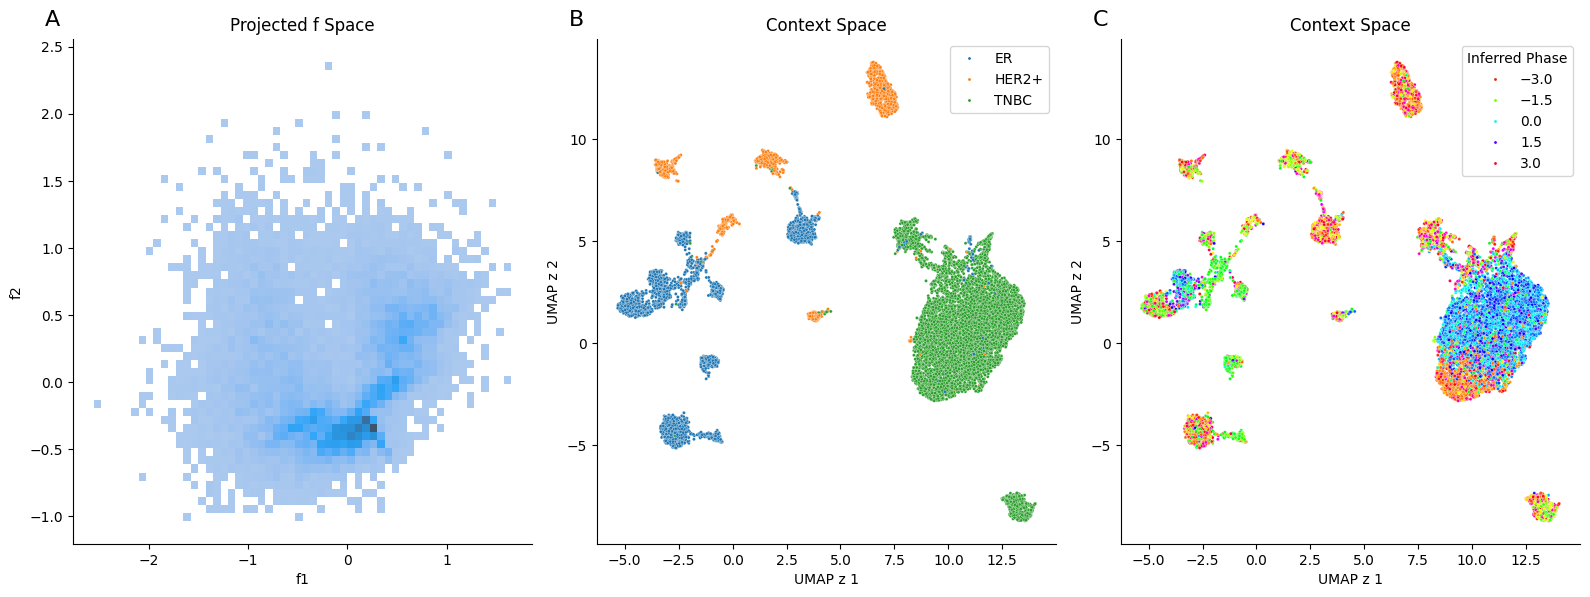

Latent space visualization of the inferred cell cycle phases.
    
A. Histogram of the projected f space, which defines the inferred phase. 
(Seeing an annulus is a good signal, but this depends on the weight of Trainer's closed_circle_weight)

B. Context space colored by the provided hue (if any).

C. Context space colored by the inferred phase. 
(You should see a ~ random distribution of the inferred phases in the context space, since the mutual
information between the context and the inferred phase is minimized.)



In [73]:
plotting.plot_cell_cycle_validations(
    model,
    space_outputs,
    generative_outputs,
    adata,
    layer="total",
    hue_key="cancer_type",
)

Here you can see an example of failure when the entropy is too low, then the model converge to a non biological solution where PCNA and MCM6 for instance are predicted to have twice high values in a cycle (B), which is wrong. Moreover the library size increase is too high (D), the histones do not display a clear window (C), and the genes in E are not well separated by phase. Increasing the ``entropy_weight_factor=10`` (that I had decreased to showcase this), should help.

Epoch 1/200, elbo_loss: 759.28, phase distribution:  ⚠ non-uniform, (summed losses: 516.43)
Epoch 2/200, elbo_loss: 652.17, phase distribution:  ⚠ non-uniform, (summed losses: 355.70)
Epoch 3/200, elbo_loss: 608.52, phase distribution: slightly non-uniform, (summed losses: 305.56)
Epoch 4/200, elbo_loss: 584.06, phase distribution: slightly non-uniform, (summed losses: 277.85)
Epoch 5/200, elbo_loss: 568.52, phase distribution: slightly non-uniform, (summed losses: 261.24)
Epoch 6/200, elbo_loss: 557.74, phase distribution: slightly non-uniform, (summed losses: 250.71)
Epoch 7/200, elbo_loss: 550.06, phase distribution: slightly non-uniform, (summed losses: 243.01)
Epoch 8/200, elbo_loss: 544.44, phase distribution: slightly non-uniform, (summed losses: 237.14)
Epoch 9/200, elbo_loss: 539.99, phase distribution: slightly non-uniform, (summed losses: 232.96)
Epoch 10/200, elbo_loss: 536.38, phase distribution: slightly non-uniform, (summed losses: 228.20)
Epoch 11/200, elbo_loss: 534.08

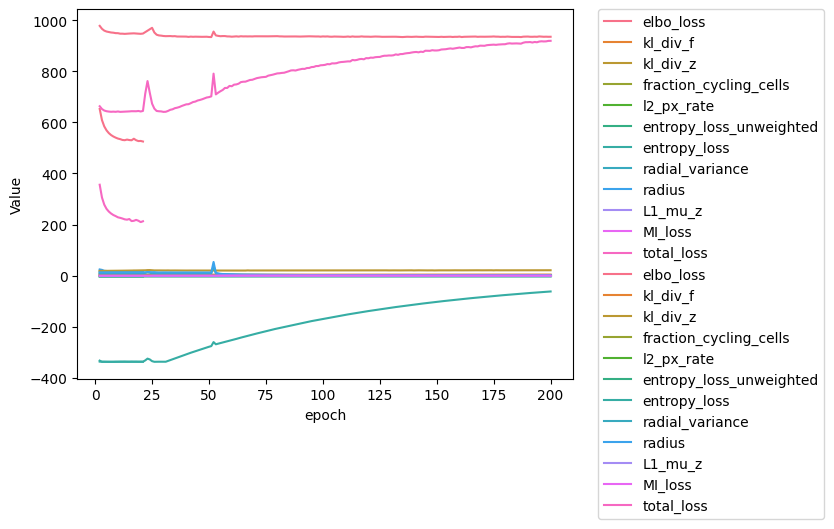

In [83]:
model = CoPhaser(
    SMALL_CYCLING_GENE_SET,
    context_genes=context_genes,
)
model.load_anndata(adata, layer_to_use="total")
trainer = Trainer(
    model,
    Loss.compute_loss,
    closed_circle_weight=100,
)
trainer.train_model()

<Axes: xlabel='None', ylabel='Count'>

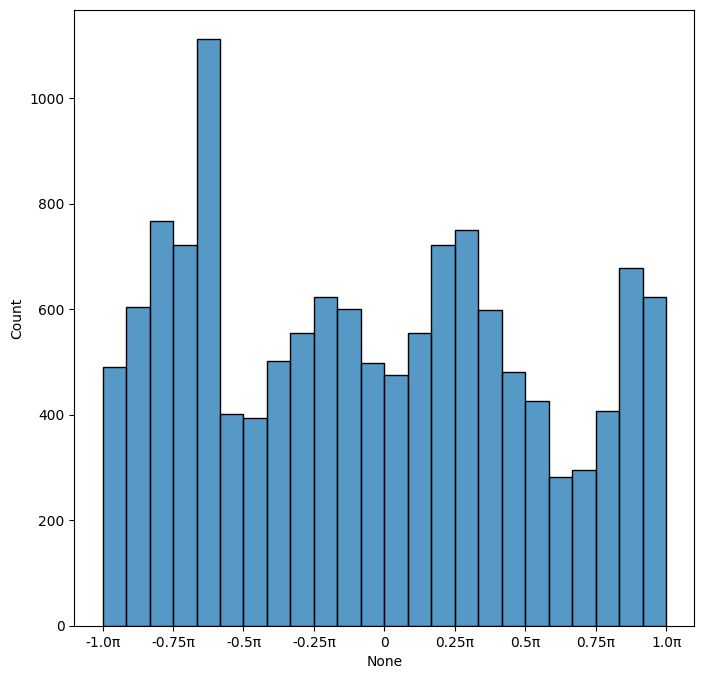

In [84]:
# Get the infered theta values
model.to("cpu")
generative_outputs, space_outputs = model.get_outputs()
thetas = space_outputs["theta"]
plotting.modify_axis_labels()
sns.histplot(x=thetas)

54 histone genes found in data
Getting posterior and calculating entropy...


100%|██████████| 20/20 [00:00<00:00, 57.04it/s]


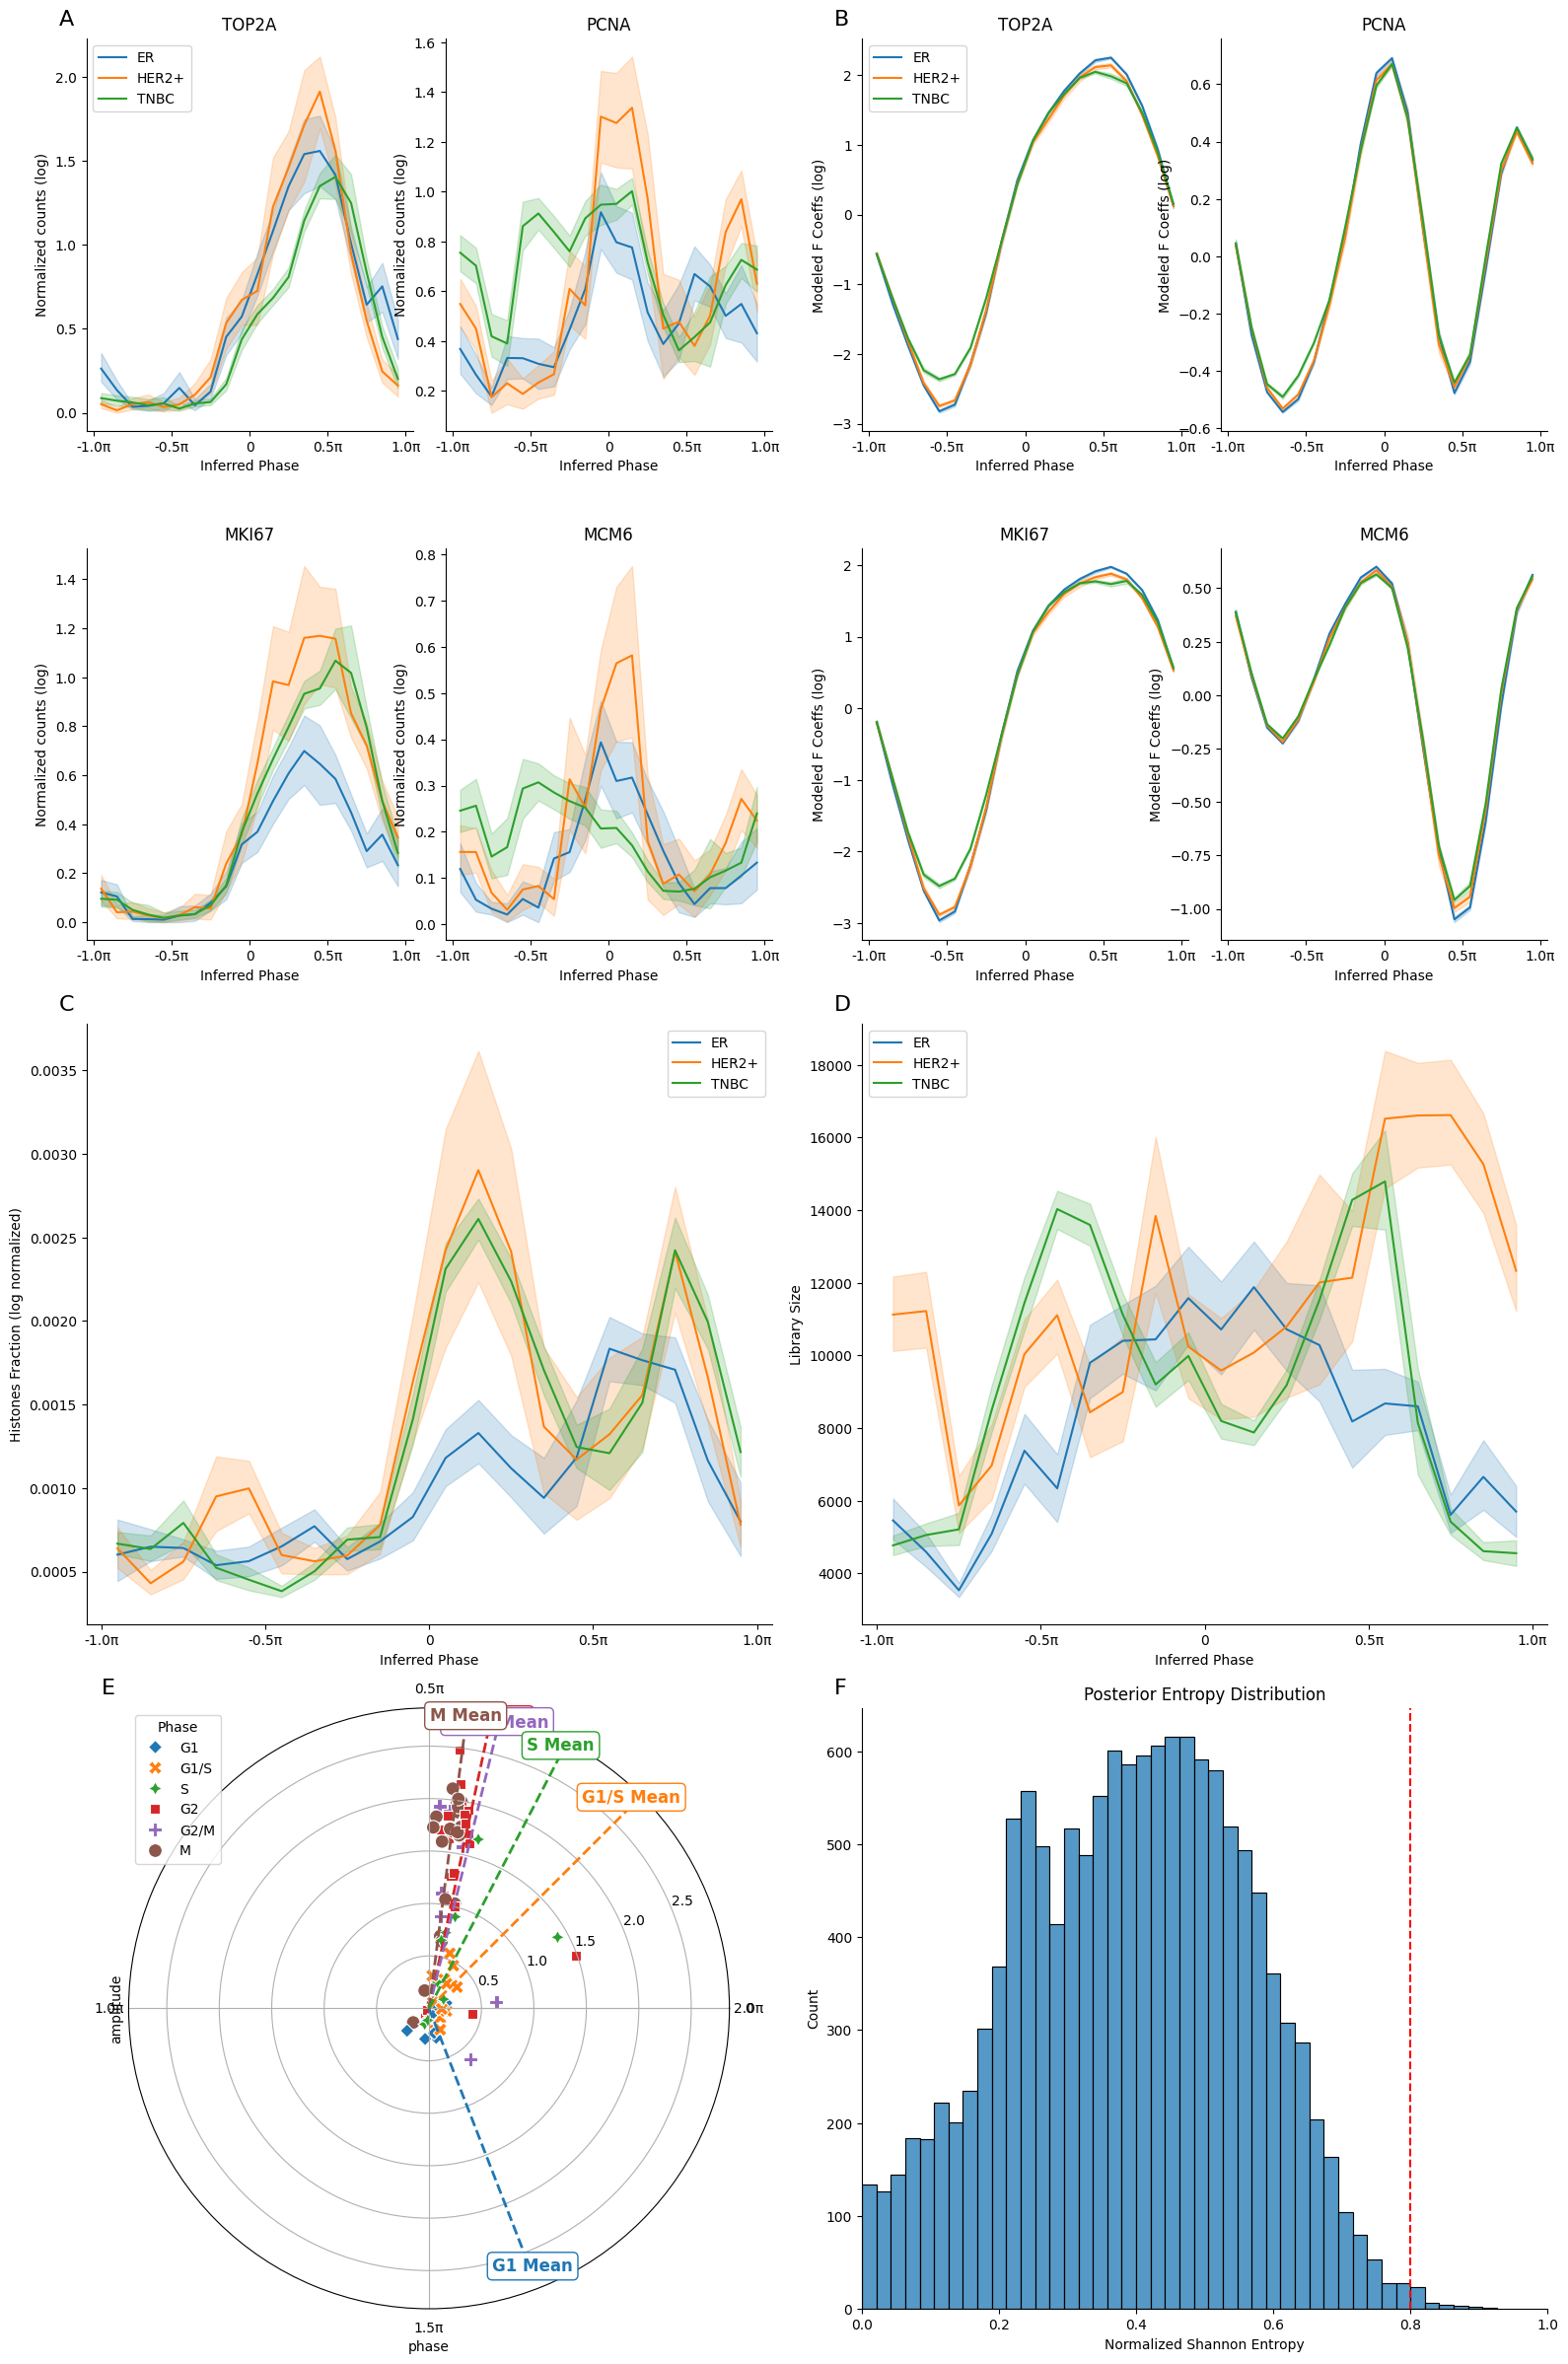

Validation of the inferred cell cycle phases.

A. Reconstructed gene expression profiles, obtained by binning cells according to inferred phase and averaging 
log(1 + counts per 10,000) for the indicated gene.
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.
If Top2a/Mki67 are not in phase and phase shifted with respect to Pcna/Mcm6, the inferred phases are wrong.)

B. Fourier derived predicted gene expression profiles in log
(You should see: Top2a 2-3 log, peak G2M; Mki67 2-3 log, peak G2M; Pcna 1-2 log, peak S; Mcm6 1-2 log, peak S.)

C. Histone fraction in function of inferred phase.
(You should see a peak during the S phase (see D and E to determine the S phase).)

D. Library size in function of inferred phase.
(You should ~see a doubling of the library size.)

E. Scatter plot of the inferred peaking phases and amplitudes of annotated cell cycle genes.
(You should ~see a progression from G1-G1/S-S-G2-M.)

F. Distribution

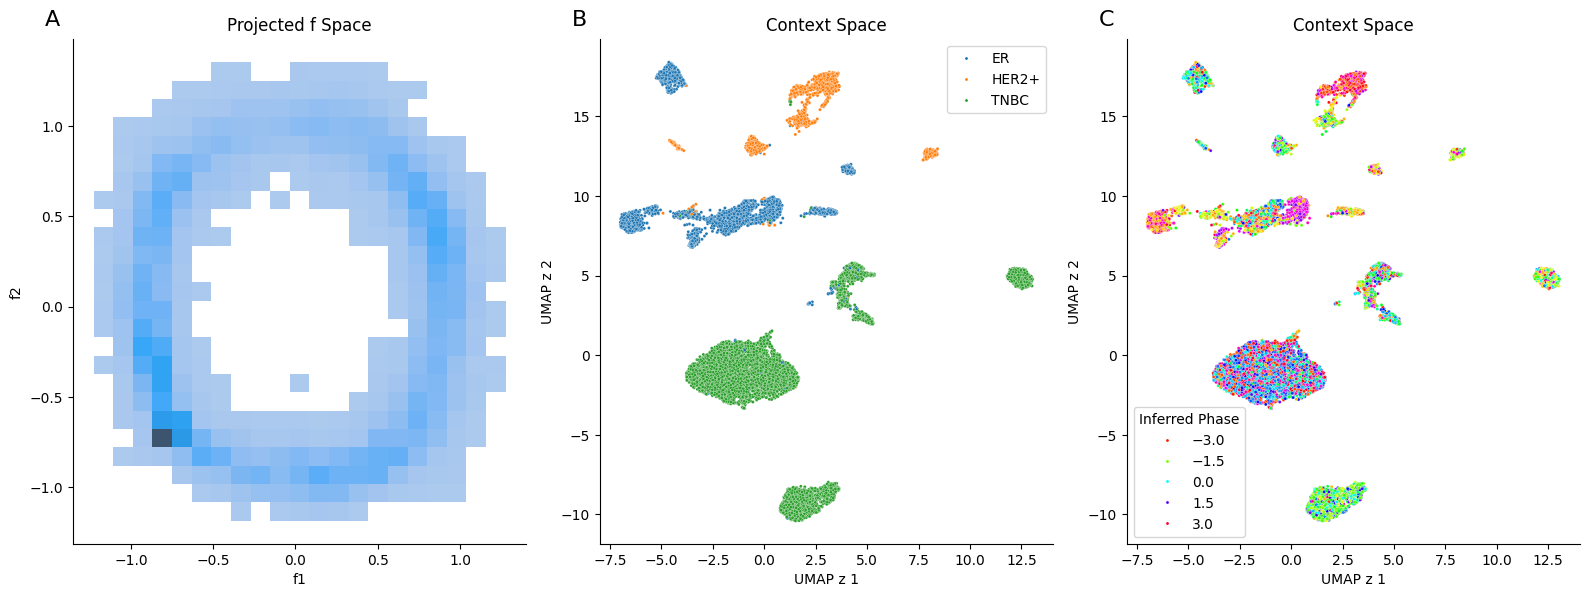

Latent space visualization of the inferred cell cycle phases.
    
A. Histogram of the projected f space, which defines the inferred phase. 
(Seeing an annulus is a good signal, but this depends on the weight of Trainer's closed_circle_weight)

B. Context space colored by the provided hue (if any).

C. Context space colored by the inferred phase. 
(You should see a ~ random distribution of the inferred phases in the context space, since the mutual
information between the context and the inferred phase is minimized.)



In [85]:
plotting.plot_cell_cycle_validations(
    model,
    space_outputs,
    generative_outputs,
    adata,
    layer="total",
    hue_key="cancer_type",
)

Similarly, if you put too much weight on the ``closed_circle_weight``, this will hurt the optimization and eventhough you get a perfect cycle in second pannel A, the pannel 1 looks similar to the one with not enough entropy.